In [1]:
from datetime import date, timedelta
from IPython.display import display

import polars as pl
import numpy as np

from mars import MarsDataProfiler
from mars import MarsNativeBinner, MarsOptimalBinner
from mars import MarsBinEvaluator
from mars.utils.logger import set_log_level

pl.Config.set_fmt_str_lengths(100)
set_log_level("WARNING")

In [2]:
import sklearn
sklearn.__version__

'1.7.2'

In [3]:
np.random.seed(2024)
N_MONTHS = 4       
N_SAMPLES = 20000     
BASE_DATE = date(2024, 1, 1)

data_parts = []

print(f"🛠️  正在生成 20 个特征的模拟数据 ({N_MONTHS} 个月 x {N_SAMPLES} 样本)...")

for i in range(N_MONTHS):
    curr_month = BASE_DATE + timedelta(days=31 * i)
    month_data = {
        "apply_date": [curr_month] * N_SAMPLES
    }
    
    # 初始 Logits 偏置
    # 设置为 -3.0，使基础坏账率保持在 4.7% 左右 (Sigmoid(-3) ≈ 0.047)
    total_logits = np.full(N_SAMPLES, -3.0) 
    
    # -------------------------------------------------
    # A组: [00-04] 稳定特征 (Stable)
    # -------------------------------------------------
    # 模拟信用评分、收入等级等强特征
    for k in range(5):
        feat_name = f"feat_stable_{k:02d}"
        raw_val = np.random.normal(0, 1, N_SAMPLES)
        
        # 降低系数 (0.3 ~ 0.5)，避免单特征 IV 爆炸
        coef = np.random.choice([0.3, -0.3, 0.5, -0.4])
        total_logits += coef * raw_val
        
        # 少量缺失 (1%)
        val_with_nan = raw_val.copy()
        mask_nan = np.random.rand(N_SAMPLES) < 0.01
        val_with_nan[mask_nan] = np.nan
        month_data[feat_name] = val_with_nan

    # -------------------------------------------------
    # B组: [05-09] 漂移特征 (Drift)
    # -------------------------------------------------
    # 模拟某些政策变动导致的客群偏移
    for k in range(5):
        feat_name = f"feat_drift_{k:02d}"
        
        # 漂移幅度温和一点：半年偏移 0.5 个标准差
        drift_amount = i * 0.1 
        raw_val = np.random.normal(loc=drift_amount, scale=1, size=N_SAMPLES)
        
        # 弱相关 (0.1)，即使漂移也不会导致 badrate 剧烈波动
        total_logits += 0.1 * raw_val 
        
        val_with_nan = raw_val.copy()
        val_with_nan[np.random.rand(N_SAMPLES) < 0.05] = np.nan
        month_data[feat_name] = val_with_nan

    # -------------------------------------------------
    # C组: [10-14] 缺失恶化特征 (MissInc)
    # -------------------------------------------------
    # 模拟三方数据接口不稳定性
    for k in range(5):
        feat_name = f"feat_miss_{k:02d}"
        raw_val = np.random.normal(0, 1, N_SAMPLES)
        
        # 这种特征通常还是有点用的
        total_logits += 0.2 * raw_val
        
        # 缺失率从 70% -> 95%
        miss_rate = 0.7 + (i * 0.05) 
        val_with_nan = raw_val.copy()
        val_with_nan[np.random.rand(N_SAMPLES) < miss_rate] = np.nan
        month_data[feat_name] = val_with_nan

    # -------------------------------------------------
    # D组: [15-19] 纯噪声特征 (Noise)
    # -------------------------------------------------
    for k in range(5):
        feat_name = f"feat_noise_{k:02d}"
        raw_val = np.random.normal(0, 2, N_SAMPLES)
        # 完全不加入 total_logits
        month_data[feat_name] = raw_val

    # -------------------------------------------------
    # 生成 dpd7_45d
    # -------------------------------------------------
    # 增加随机噪声项，模拟模型无法解释的部分
    # scale=1.0 保证信噪比合理，坏账率不会非0即1
    total_logits += np.random.normal(0, 1.0, N_SAMPLES)
    
    probs = 1 / (1 + np.exp(-total_logits))
    dpd7_45d = (np.random.rand(N_SAMPLES) < probs).astype(int)
    
    month_data["dpd7_45d"] = dpd7_45d
    
    # 统计当月坏账率
    bad_rate = dpd7_45d.mean()
    print(f"  - Month {i+1}: Bad Rate = {bad_rate:.2%}")
    
    data_parts.append(pl.DataFrame(month_data))

# 合并
df_test: pl.DataFrame = pl.concat(data_parts)
df_test = df_test.with_columns(pl.col("apply_date").cast(pl.String))
# df_test = df_test.to_pandas()

print("-" * 50)
print(f"✅ 数据生成完毕! Shape: {df_test.shape}")
print(f"   全局坏账率: {df_test['dpd7_45d'].mean():.2%}")
print("-" * 50)


🛠️  正在生成 20 个特征的模拟数据 (4 个月 x 20000 样本)...
  - Month 1: Bad Rate = 8.95%
  - Month 2: Bad Rate = 9.46%
  - Month 3: Bad Rate = 9.83%
  - Month 4: Bad Rate = 10.03%
--------------------------------------------------
✅ 数据生成完毕! Shape: (80000, 22)
   全局坏账率: 9.56%
--------------------------------------------------


In [4]:
df_test.head()

apply_date,feat_stable_00,feat_stable_01,feat_stable_02,feat_stable_03,feat_stable_04,feat_drift_00,feat_drift_01,feat_drift_02,feat_drift_03,feat_drift_04,feat_miss_00,feat_miss_01,feat_miss_02,feat_miss_03,feat_miss_04,feat_noise_00,feat_noise_01,feat_noise_02,feat_noise_03,feat_noise_04,dpd7_45d
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""2024-01-01""",1.668047,0.001636,-0.369792,-1.788306,0.456893,0.558442,0.572631,1.000406,1.312962,1.100726,NaN,-0.387719,0.186176,NaN,0.619361,-2.046308,2.272591,2.792012,1.007653,-1.36604,1
"""2024-01-01""",0.737348,0.43103,0.704325,-0.646752,-0.339895,1.272808,-1.481064,0.762491,0.156319,1.133006,NaN,NaN,NaN,NaN,NaN,0.437779,0.419399,-2.19845,-0.033999,0.046231,0
"""2024-01-01""",-0.201538,-0.269814,0.293191,-0.289382,-2.080532,-1.66749,-0.190527,0.252458,-1.884677,1.454692,-0.850332,NaN,-0.605657,0.679121,NaN,2.524236,1.556764,2.372679,1.951594,2.254981,0
"""2024-01-01""",-0.150912,0.107329,-1.788568,-0.313834,-1.39575,-0.911884,-0.805904,NaN,-0.496687,-0.669048,-0.200391,NaN,-0.591411,-0.085521,NaN,1.337186,-3.203901,-0.838905,0.146901,-3.287832,0
"""2024-01-01""",0.916052,-0.0137,0.071821,0.168971,1.053674,-0.145678,NaN,0.295431,0.491123,-0.367002,-0.302291,0.686308,NaN,NaN,NaN,1.685961,3.22031,-1.081754,-2.042914,-0.734279,0


In [5]:
df_test.describe()

statistic,apply_date,feat_stable_00,feat_stable_01,feat_stable_02,feat_stable_03,feat_stable_04,feat_drift_00,feat_drift_01,feat_drift_02,feat_drift_03,feat_drift_04,feat_miss_00,feat_miss_01,feat_miss_02,feat_miss_03,feat_miss_04,feat_noise_00,feat_noise_01,feat_noise_02,feat_noise_03,feat_noise_04,dpd7_45d
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""80000""",80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0,80000.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003918,0.007205,0.00965,0.004013,0.00212,0.09565
"""std""",null,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.998651,2.001277,1.992375,1.996148,1.989634,0.294112
"""min""","""2024-01-01""",-4.659177,-4.390396,-4.407705,-4.102802,-3.951435,-3.914277,-4.287416,-4.170083,-4.036734,-4.782146,-3.607031,-4.103873,-4.358812,-3.635214,-4.25254,-8.283695,-8.520235,-8.598979,-8.501689,-8.396221,0.0
"""25%""",null,-0.670406,-0.664779,-0.669502,-0.672706,-0.675402,-0.499494,-0.486271,-0.488074,-0.481823,-0.484341,NaN,NaN,NaN,NaN,NaN,-1.357843,-1.338742,-1.347859,-1.349929,-1.344758,0.0
"""50%""",null,0.012304,0.006966,0.001033,0.006477,0.003599,0.20419,0.214599,0.217054,0.215921,0.220388,NaN,NaN,NaN,NaN,NaN,0.000934,0.010697,0.017464,0.011398,0.005931,0.0
"""75%""",null,0.700743,0.694304,0.69242,0.689478,0.696862,0.955565,0.964145,0.955728,0.953362,0.958258,NaN,NaN,NaN,NaN,NaN,1.345915,1.358798,1.348465,1.351258,1.346236,0.0
"""max""","""2024-04-03""",4.402141,4.274114,5.088348,3.970648,4.664161,4.499981,4.465295,4.50833,4.350508,4.745254,4.126921,4.216725,3.936684,4.200971,4.314615,7.977524,8.411534,8.165473,8.71499,9.245517,1.0


In [6]:
features = [col for col in df_test.columns if col.startswith("feat_")]
len(features)

20

In [7]:
features = [col for col in df_test.columns if col.startswith("feat_")]
test_profiler = MarsDataProfiler(
    df=df_test,
    features=features,
    exclude_features = None,
    include_dtypes = None,
    missing_values = None,
    special_values = None,
    overview_batch_size = 500,
    psi_batch_size = 50,
    psi_n_bins = 10,
    psi_bin_method = "quantile",
    psi_cv_ignore_threshold = 0.05,
    sample_frac = None,
    config = None
)

In [8]:
test_profiler_report = test_profiler.generate_profile(
    profile_by="month",
    dt_col="apply_date",
    config_overrides={
        "dq_metrics": ["missing", "zeros", "top1"],
        "stat_metrics": ["mean", "std", "min", "max",]
    }
)
test_profiler_report

In [9]:
test_profiler_report.show_overview()

feature,dtype,distribution,missing_rate,zeros_rate,top1_ratio,top1_value,mean,std,min,max
feat_drift_00,Float64,▂▂▄█▇▃▂▂,4.92%,0.00%,4.92%,NaN,0.14,1.01,-3.91,4.50
feat_drift_01,Float64,▂▂▃▇█▄▂▂,5.00%,0.00%,5.00%,NaN,0.15,1.01,-4.29,4.47
feat_drift_02,Float64,▂▂▄█▇▄▂▂,4.96%,0.00%,4.96%,NaN,0.15,1.01,-4.17,4.51
feat_drift_03,Float64,▂▂▄█▇▄▂▂,4.98%,0.00%,4.98%,NaN,0.15,1.00,-4.04,4.35
feat_drift_04,Float64,▂▂▃▆█▄▂▂,4.98%,0.00%,4.98%,NaN,0.15,1.00,-4.78,4.75
feat_miss_00,Float64,▂▂▅█▆▃▂▂,77.47%,0.00%,77.47%,NaN,-0.00,0.99,-3.61,4.13
feat_miss_01,Float64,▂▂▄█▇▄▂▂,77.58%,0.00%,77.58%,NaN,-0.00,1.00,-4.10,4.22
feat_miss_02,Float64,▂▂▃▆█▄▂▂,77.46%,0.00%,77.46%,NaN,0.00,1.00,-4.36,3.94
feat_miss_03,Float64,▂▂▅█▆▃▂▂,77.39%,0.00%,77.39%,NaN,0.00,1.00,-3.64,4.20
feat_miss_04,Float64,▂▂▄█▇▄▂▂,77.72%,0.00%,77.72%,NaN,0.01,1.00,-4.25,4.31


In [10]:
test_profiler_report.show_trend("missing", ascending=False)

feature,dtype,2024-04-01,2024-03-01,2024-02-01,2024-01-01,total
feat_drift_00,Float64,4.84%,4.78%,5.13%,4.93%,4.92%
feat_drift_01,Float64,5.15%,4.92%,5.01%,4.94%,5.00%
feat_drift_02,Float64,5.16%,5.02%,4.98%,4.67%,4.96%
feat_drift_03,Float64,5.07%,5.22%,4.70%,4.91%,4.98%
feat_drift_04,Float64,5.03%,4.92%,4.95%,5.02%,4.98%
feat_miss_00,Float64,84.80%,80.03%,75.11%,69.95%,77.47%
feat_miss_01,Float64,85.30%,80.12%,74.83%,70.05%,77.58%
feat_miss_02,Float64,84.76%,79.93%,74.74%,70.41%,77.46%
feat_miss_03,Float64,85.06%,80.09%,74.31%,70.10%,77.39%
feat_miss_04,Float64,85.08%,80.54%,75.27%,70.00%,77.72%


In [11]:
test_profiler_report.show_trend("mean")

feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,total,group_mean,group_var,group_cv
feat_drift_00,Float64,-0.02,0.09,0.20,0.30,0.14,0.14,0.0180,0.9461
feat_drift_01,Float64,0.00,0.09,0.21,0.31,0.15,0.15,0.0181,0.8828
feat_drift_02,Float64,-0.01,0.10,0.21,0.30,0.15,0.15,0.0179,0.8936
feat_drift_03,Float64,-0.01,0.11,0.19,0.30,0.15,0.15,0.0175,0.8880
feat_drift_04,Float64,0.01,0.10,0.20,0.30,0.15,0.15,0.0156,0.8212
feat_miss_00,Float64,-0.01,0.01,0.00,0.01,-0.00,0.00,0.0001,13.1305
feat_miss_01,Float64,-0.01,-0.00,0.02,-0.03,-0.00,-0.00,0.0004,4.1241
feat_miss_02,Float64,-0.01,0.02,0.00,-0.00,0.00,0.00,0.0002,7.2905
feat_miss_03,Float64,-0.00,0.01,-0.00,0.00,0.00,0.00,0.0000,13.0104
feat_miss_04,Float64,0.01,-0.00,0.01,0.02,0.01,0.01,0.0001,0.8963


In [12]:
overview, dq_table, stat_table = test_profiler_report.get_profile_data()
display(overview.head(), dq_table["missing"].head())

feature,dtype,distribution,missing_rate,zeros_rate,top1_ratio,top1_value,mean,std,min,max
str,str,str,f64,f64,f64,str,f64,f64,f64,f64
"""feat_drift_00""","""Float64""","""▂▂▄█▇▃▂▂""",0.0492375,0.0,0.0492375,"""NaN""",0.141872,1.008353,-3.914277,4.499981
"""feat_drift_01""","""Float64""","""▂▂▃▇█▄▂▂""",0.05005,0.0,0.05005,"""NaN""",0.152438,1.00883,-4.287416,4.465295
"""feat_drift_02""","""Float64""","""▂▂▄█▇▄▂▂""",0.0496,0.0,0.0496,"""NaN""",0.149499,1.00602,-4.170083,4.50833
"""feat_drift_03""","""Float64""","""▂▂▄█▇▄▂▂""",0.04975,0.0,0.04975,"""NaN""",0.14899,1.004284,-4.036734,4.350508
"""feat_drift_04""","""Float64""","""▂▂▃▆█▄▂▂""",0.0498,0.0,0.0498,"""NaN""",0.152301,1.003099,-4.782146,4.745254


feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,total
str,str,f64,f64,f64,f64,f64
"""feat_drift_00""","""Float64""",0.04935,0.05135,0.0478,0.04845,0.0492375
"""feat_drift_01""","""Float64""",0.0494,0.0501,0.04925,0.05145,0.05005
"""feat_drift_02""","""Float64""",0.04675,0.04985,0.0502,0.0516,0.0496
"""feat_drift_03""","""Float64""",0.0491,0.04695,0.05225,0.0507,0.04975
"""feat_drift_04""","""Float64""",0.0502,0.04945,0.04925,0.0503,0.0498


In [13]:
# (
#     overview
#     .filter(pl.col("missing_rate") < 0.8)
#     .select("feature")
#     .to_series()
#     .to_list()
# )

In [14]:
test_native_binner = MarsNativeBinner(
    features=features,
    method = "quantile",
    n_bins = 9,
    special_values = None,
    missing_values = None,
    min_samples = 0.05, # 仅对 cart 有效
    cart_params = None,
    remove_empty_bins = False, # 仅对 uniform 有效
    n_jobs = -1
)
test_native_binner.fit(df_test, df_test["dpd7_45d"])

,features,"['feat_stable_00', 'feat_stable_01', ...]"
,method,'quantile'
,n_bins,9
,special_values,[]
,missing_values,[]
,min_samples,0.05
,cart_params,{}
,remove_empty_bins,False
,n_jobs,23


In [15]:
trans_cols = ["feat_stable_00", "feat_drift_00", "feat_miss_00", "feat_noise_00"]
display(test_native_binner.transform(df_test[trans_cols], return_type ="label", lazy=True).collect().head(3))
display(test_native_binner.transform(df_test[trans_cols], return_type ="index").head(3))
display(test_native_binner.transform(df_test[trans_cols], return_type ="woe").head(3))

feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
f64,f64,f64,f64,str,str,str,str
1.668047,0.558442,NaN,-2.046308,"""05_[0.28, 0.575)""","""08_[1.23, inf)""","""01_[-2.44, -1.54)""","""Missing"""
0.737348,1.272808,NaN,0.437779,"""07_[0.916, 1.37)""","""06_[0.43, 0.767)""","""05_[0.279, 0.867)""","""Missing"""
-0.201538,-1.66749,-0.850332,2.524236,"""00_[-inf, -1.09)""","""03_[-0.435, -0.142)""","""08_[2.44, inf)""","""01_[-1.22, -0.778)"""


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
f64,f64,f64,f64,i16,i16,i16,i16
1.668047,0.558442,NaN,-2.046308,5,8,1,-1
0.737348,1.272808,NaN,0.437779,7,6,5,-1
-0.201538,-1.66749,-0.850332,2.524236,0,3,8,1


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_woe,feat_stable_00_woe,feat_noise_00_woe,feat_miss_00_woe
f64,f64,f64,f64,f32,f32,f32,f32
1.668047,0.558442,NaN,-2.046308,0.025269,-0.16974,0.069261,0.008144
0.737348,1.272808,NaN,0.437779,0.141669,-0.089145,0.01135,0.008144
-0.201538,-1.66749,-0.850332,2.524236,-0.136366,0.057102,-0.003032,-0.224941


In [16]:
test_native_bin_performance_table = test_native_binner.profile_bin_performance(df_test[features], df_test["dpd7_45d"], update_woe=True)
test_native_bin_performance_table

feature,bin_label,trend_shape,count,bad,good,count_dist,bad_rate,bad_dist,good_dist,woe,bin_iv,cum_bad_dist,cum_good_dist,bin_ks,IV,KS,AUC,Lift
str,str,str,u32,i64,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""feat_drift_00""","""00_[-inf, -1.09)""","""undefined""",8451,714,7737,0.105637,0.084487,0.093309,0.106941,-0.136366,0.001859,0.093309,0.106941,0.013633,0.009518,0.040768,0.526927,0.883284
"""feat_drift_00""","""01_[-1.09, -0.633)""","""undefined""",8451,750,7701,0.105637,0.088747,0.098014,0.106444,-0.082512,0.000696,0.191323,0.213385,0.022063,0.009518,0.040768,0.526927,0.92782
"""feat_drift_00""","""02_[-0.633, -0.296)""","""undefined""",8451,750,7701,0.105637,0.088747,0.098014,0.106444,-0.082512,0.000696,0.289336,0.319829,0.030493,0.009518,0.040768,0.526927,0.92782
"""feat_drift_00""","""03_[-0.296, -0.00387)""","""undefined""",8451,759,7692,0.105637,0.089812,0.09919,0.106319,-0.069414,0.000495,0.388526,0.426149,0.037623,0.009518,0.040768,0.526927,0.938954
"""feat_drift_00""","""04_[-0.00387, 0.28)""","""undefined""",8452,815,7637,0.10565,0.096427,0.106508,0.105559,0.008949,0.000008,0.541427,0.581246,0.039819,0.009518,0.040768,0.526927,1.008112
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat_stable_04""","""05_[0.134, 0.43)""","""descending""",8799,781,8018,0.109987,0.08876,0.102065,0.110825,-0.082348,0.000721,0.389963,0.445237,0.055273,0.020419,0.060367,0.540005,0.927958
"""feat_stable_04""","""06_[0.43, 0.763)""","""descending""",8798,770,8028,0.109975,0.08752,0.100627,0.110964,-0.097779,0.001011,0.287899,0.334411,0.046513,0.020419,0.060367,0.540005,0.914992
"""feat_stable_04""","""07_[0.763, 1.22)""","""descending""",8799,744,8055,0.109987,0.084555,0.097229,0.111337,-0.135486,0.001911,0.187271,0.223448,0.036176,0.020419,0.060367,0.540005,0.883996


In [17]:
trans_cols = ["feat_stable_00", "feat_drift_00", "feat_miss_00", "feat_noise_00"]
display(test_native_binner.transform(df_test[trans_cols], return_type ="label", lazy=True).collect().head(3))
display(test_native_binner.transform(df_test[trans_cols], return_type ="index").head(3))
display(test_native_binner.transform(df_test[trans_cols], return_type ="woe").head(3))

feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
f64,f64,f64,f64,str,str,str,str
1.668047,0.558442,NaN,-2.046308,"""05_[0.28, 0.575)""","""08_[1.23, inf)""","""01_[-2.44, -1.54)""","""Missing"""
0.737348,1.272808,NaN,0.437779,"""07_[0.916, 1.37)""","""06_[0.43, 0.767)""","""05_[0.279, 0.867)""","""Missing"""
-0.201538,-1.66749,-0.850332,2.524236,"""00_[-inf, -1.09)""","""03_[-0.435, -0.142)""","""08_[2.44, inf)""","""01_[-1.22, -0.778)"""


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
f64,f64,f64,f64,i16,i16,i16,i16
1.668047,0.558442,NaN,-2.046308,5,8,1,-1
0.737348,1.272808,NaN,0.437779,7,6,5,-1
-0.201538,-1.66749,-0.850332,2.524236,0,3,8,1


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_woe,feat_stable_00_woe,feat_noise_00_woe,feat_miss_00_woe
f64,f64,f64,f64,f32,f32,f32,f32
1.668047,0.558442,NaN,-2.046308,0.025269,-0.16974,0.069261,0.008144
0.737348,1.272808,NaN,0.437779,0.141669,-0.089145,0.01135,0.008144
-0.201538,-1.66749,-0.850332,2.524236,-0.136366,0.057102,-0.003032,-0.224941


In [18]:
test_opt_biner = MarsOptimalBinner(
    features=features,
    cat_features = None,
    n_bins = 10,
    min_n_bins = 1,
    min_bin_size = 0.02,
    n_prebins = 20,
    prebinning_method = "cart",
    min_prebin_size = 0.01,
    monotonic_trend = "auto_asc_desc",
    solver = "cp",
    time_limit = 2,
    special_values = None,
    missing_values = None,
    cart_params = {"random_state": 2025},
    n_jobs = -1
)
test_opt_biner.fit(df_test, df_test["dpd7_45d"])

,features,"['feat_stable_00', 'feat_stable_01', ...]"
,cat_features,[]
,n_bins,10
,min_n_bins,1
,min_bin_size,0.02
,min_bin_n_event,3
,prebinning_method,'cart'
,n_prebins,20
,min_prebin_size,0.01
,monotonic_trend,'auto_asc_desc'
,solver,'cp'


In [19]:
test_opt_biner.fit_failures_

{}

In [20]:
trans_cols = ["feat_stable_00", "feat_drift_00", "feat_miss_00", "feat_noise_00"]
display(test_opt_biner.transform(df_test[trans_cols], return_type ="label", lazy=True).collect().head(3))
display(test_opt_biner.transform(df_test[trans_cols], return_type ="index").head(3))
display(test_opt_biner.transform(df_test[trans_cols], return_type ="woe").head(3))

feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
f64,f64,f64,f64,str,str,str,str
1.668047,0.558442,NaN,-2.046308,"""03_[0.0774, 0.808)""","""05_[1.14, inf)""","""00_[-inf, 0.603)""","""Missing"""
0.737348,1.272808,NaN,0.437779,"""06_[1.27, 1.8)""","""04_[0.0983, 1.14)""","""00_[-inf, 0.603)""","""Missing"""
-0.201538,-1.66749,-0.850332,2.524236,"""00_[-inf, -1.58)""","""02_[-0.947, -0.111)""","""02_[1.16, 3.74)""","""01_[-1.16, -0.49)"""


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
f64,f64,f64,f64,i16,i16,i16,i16
1.668047,0.558442,NaN,-2.046308,3,5,0,-1
0.737348,1.272808,NaN,0.437779,6,4,0,-1
-0.201538,-1.66749,-0.850332,2.524236,0,2,2,1


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_woe,feat_stable_00_woe,feat_noise_00_woe,feat_miss_00_woe
f64,f64,f64,f64,f32,f32,f32,f32
1.668047,0.558442,NaN,-2.046308,0.030675,-0.189565,0.026851,0.008144
0.737348,1.272808,NaN,0.437779,0.158384,-0.080264,0.026851,0.008144
-0.201538,-1.66749,-0.850332,2.524236,-0.237073,0.03528,-0.049829,-0.200117


In [21]:
test_opt_bin_performance_table = test_opt_biner.profile_bin_performance(df_test[features], df_test["dpd7_45d"])
test_opt_bin_performance_table

feature,bin_label,trend_shape,count,bad,good,count_dist,bad_rate,bad_dist,good_dist,woe,bin_iv,cum_bad_dist,cum_good_dist,bin_ks,IV,KS,AUC,Lift
str,str,str,u32,i64,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""feat_drift_00""","""00_[-inf, -1.58)""","""ascending""",3298,254,3044,0.041225,0.077016,0.033194,0.042074,-0.237073,0.002105,0.033194,0.042074,0.00888,0.011973,0.045736,0.52924,0.805181
"""feat_drift_00""","""01_[-1.58, -0.2)""","""ascending""",24718,2189,22529,0.308975,0.088559,0.286069,0.311398,-0.084838,0.002149,0.319263,0.353472,0.034209,0.011973,0.045736,0.52924,0.925855
"""feat_drift_00""","""02_[-0.2, 0.0774)""","""ascending""",8207,727,7480,0.102587,0.088583,0.095008,0.103389,-0.084541,0.000709,0.414271,0.456861,0.04259,0.011973,0.045736,0.52924,0.926105
"""feat_drift_00""","""03_[0.0774, 0.808)""","""ascending""",20379,2004,18375,0.254737,0.098337,0.261892,0.253981,0.030675,0.000243,0.722556,0.76038,0.037824,0.011973,0.045736,0.52924,1.028076
"""feat_drift_00""","""04_[0.808, 0.918)""","""ascending""",2609,268,2341,0.032612,0.102721,0.035024,0.032357,0.079174,0.000211,0.75758,0.792738,0.035158,0.011973,0.045736,0.52924,1.073918
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat_stable_04""","""03_[-0.489, 0.498)""","""descending""",29777,2750,27027,0.372212,0.092353,0.359383,0.373569,-0.038715,0.000549,0.621798,0.683585,0.061787,0.024112,0.061787,0.541954,0.965522
"""feat_stable_04""","""04_[0.498, 0.699)""","""descending""",5284,461,4823,0.06605,0.087245,0.060246,0.066664,-0.101233,0.00065,0.262415,0.310015,0.0476,0.024112,0.061787,0.541954,0.912113
"""feat_stable_04""","""05_[0.699, 1.39)""","""descending""",12789,1074,11715,0.159863,0.083978,0.140355,0.161926,-0.142959,0.003084,0.202169,0.243352,0.041182,0.024112,0.061787,0.541954,0.877967


In [22]:
test_evaluator = MarsBinEvaluator(binner=test_opt_biner, target_col="dpd7_45d")

test_evaluator_report = test_evaluator.evaluate(
    df=df_test,
    features=features,
    profile_by="month",
    dt_col="apply_date"
)

In [23]:
test_evaluator_report

In [24]:
summary_df, trend_tables, detail_table = test_evaluator_report.get_evaluation_data()
detail_table

y,feature,trend,mars_group,bin_index,bin_label,count,bad,good,pct,bad_rate,lift,cum_count,cum_bad,cum_bad_rate,psi_bin,ks_bin,auc_bin,iv_bin,total_count,bin_type
str,str,str,str,i16,str,u32,i64,i64,f64,f64,f64,u32,i64,f64,f64,f64,f64,f32,u32,str
"""dpd7_45d""","""feat_drift_00""","""ascending""","""2024-01-01""",0,"""00_[-inf, -1.58)""",1133,94,1039,0.05665,0.082966,0.92699,1133,94,0.082966,0.0,0.45426,0.001498,0.000377,20000,"""首尾组"""
"""dpd7_45d""","""feat_drift_00""","""ascending""","""2024-01-01""",1,"""01_[-1.58, -0.2)""",7008,617,6391,0.3504,0.088042,0.983712,8141,711,0.087336,0.0,1.081087,0.078917,0.000113,20000,"""正常组"""
"""dpd7_45d""","""feat_drift_00""","""ascending""","""2024-01-01""",2,"""02_[-0.2, 0.0774)""",2076,168,1908,0.1038,0.080925,0.904188,10217,879,0.086033,0.0,2.173372,0.046535,0.001203,20000,"""正常组"""
"""dpd7_45d""","""feat_drift_00""","""ascending""","""2024-01-01""",3,"""03_[0.0774, 0.808)""",4855,431,4424,0.24275,0.088774,0.991893,15072,1310,0.086916,0.0,3.146439,0.158863,0.000019,20000,"""正常组"""
"""dpd7_45d""","""feat_drift_00""","""ascending""","""2024-01-01""",4,"""04_[0.808, 0.918)""",584,49,535,0.0292,0.083904,0.937476,15656,1359,0.086804,-1.0179e-12,3.346955,0.023151,0.000142,20000,"""正常组"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""dpd7_45d""","""feat_stable_04""","""descending""","""Total""",4,"""04_[0.498, 0.699)""",5284,461,4823,0.06605,0.087245,0.912122,60037,6026,0.100371,0.000007,4.760043,0.015486,0.00065,80000,"""正常组"""
"""dpd7_45d""","""feat_stable_04""","""descending""","""Total""",5,"""05_[0.699, 1.39)""",12789,1074,11715,0.159862,0.083978,0.877976,72826,7100,0.097493,0.000006,4.118221,0.021373,0.003084,80000,"""正常组"""
"""dpd7_45d""","""feat_stable_04""","""descending""","""Total""",6,"""06_[1.39, inf)""",6364,473,5891,0.07955,0.074324,0.777045,79190,7573,0.095631,0.000009,1.961198,0.002517,0.005404,80000,"""首尾组"""


In [25]:
# test_evaluator_report.write_excel("mars_bin_report.xlsx")

In [26]:
display(test_evaluator_report.show_trend("psi", ascending=False))

feature,dtype,2024-04-01,2024-03-01,2024-02-01,2024-01-01,Total
feat_drift_00,Float64,0.0901,0.0410,0.0118,-0.0000,0.0230
feat_drift_01,Float64,0.0870,0.0401,0.0086,-0.0000,0.0213
feat_drift_02,Float64,0.0845,0.0391,0.0112,-0.0000,0.0220
feat_drift_03,Float64,0.0922,0.0379,0.0131,-0.0000,0.0228
feat_drift_04,Float64,0.0751,0.0336,0.0079,-0.0000,0.0187
feat_miss_00,Float64,0.0026,0.0037,0.0031,-0.0000,0.0012
feat_miss_01,Float64,0.0033,0.0041,0.0051,-0.0000,0.0015
feat_miss_02,Float64,0.0013,0.0024,0.0029,-0.0000,0.0010
feat_miss_03,Float64,0.0003,0.0003,0.0007,-0.0000,0.0001
feat_miss_04,Float64,0.0013,0.0001,0.0023,-0.0000,0.0002


In [27]:
display(test_evaluator_report.show_trend("iv", ascending=True))

feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,Total
feat_drift_00,Float64,0.0109,0.0244,0.0187,0.0114,0.0120
feat_drift_01,Float64,0.0039,0.0153,0.0144,0.0174,0.0101
feat_drift_02,Float64,0.0080,0.0226,0.0139,0.0067,0.0096
feat_drift_03,Float64,0.0074,0.0166,0.0208,0.0146,0.0119
feat_drift_04,Float64,0.0142,0.0169,0.0073,0.0199,0.0119
feat_miss_00,Float64,0.0139,0.0189,0.0071,0.0113,0.0085
feat_miss_01,Float64,0.0259,0.0133,0.0152,0.0159,0.0134
feat_miss_02,Float64,0.0206,0.0226,0.0094,0.0092,0.0131
feat_miss_03,Float64,0.0064,0.0116,0.0044,0.0075,0.0061
feat_miss_04,Float64,0.0073,0.0099,0.0076,0.0080,0.0068


In [28]:
display(test_evaluator_report.show_trend("risk_corr", ascending=False))

feature,dtype,2024-04-01,2024-03-01,2024-02-01,2024-01-01,Total
feat_drift_00,Float64,0.6432,0.5903,0.7283,1.0000,0.8192
feat_drift_01,Float64,0.3155,0.2979,0.5672,1.0000,0.5467
feat_drift_02,Float64,0.1466,0.8692,0.8347,1.0000,0.8410
feat_drift_03,Float64,0.7726,0.8572,0.9294,1.0000,0.9361
feat_drift_04,Float64,0.6527,0.6161,0.8190,1.0000,0.8829
feat_miss_00,Float64,0.6398,0.8646,0.6007,1.0000,0.9515
feat_miss_01,Float64,0.7931,0.8597,0.8679,1.0000,0.9610
feat_miss_02,Float64,0.9319,0.8342,0.9791,1.0000,0.9803
feat_miss_03,Float64,0.7018,0.6958,0.9246,1.0000,0.9157
feat_miss_04,Float64,0.8494,0.8596,0.8811,1.0000,0.9397


In [29]:
summary_df, trend_tables, detail_table = test_evaluator_report.get_evaluation_data()
trend_tables.keys(), type(trend_tables["auc"])

(dict_keys(['psi', 'auc', 'ks', 'iv', 'bad_rate', 'risk_corr']),
 polars.dataframe.frame.DataFrame)

In [30]:
detail_table.filter(pl.col("feature") == "feat_stable_00")

y,feature,trend,mars_group,bin_index,bin_label,count,bad,good,pct,bad_rate,lift,cum_count,cum_bad,cum_bad_rate,psi_bin,ks_bin,auc_bin,iv_bin,total_count,bin_type
str,str,str,str,i16,str,u32,i64,i64,f64,f64,f64,u32,i64,f64,f64,f64,f64,f32,u32,str
"""dpd7_45d""","""feat_stable_00""","""descending""","""2024-01-01""",0,"""00_[-inf, -1.75)""",802,134,668,0.0401,0.167082,1.866841,802,134,0.167082,0.0,5.0374e-8,0.03531,0.027232,20000,"""首尾组"""
"""dpd7_45d""","""feat_stable_00""","""descending""","""2024-01-01""",1,"""01_[-1.75, -0.947)""",2649,333,2316,0.13245,0.125708,1.404557,3451,467,0.135323,0.0,3.817719,0.105832,0.022381,20000,"""正常组"""
"""dpd7_45d""","""feat_stable_00""","""descending""","""2024-01-01""",2,"""02_[-0.947, -0.111)""",5558,544,5014,0.2779,0.097877,1.093597,9009,1011,0.112221,0.0,9.702785,0.161668,0.00282,20000,"""正常组"""
"""dpd7_45d""","""feat_stable_00""","""descending""","""2024-01-01""",3,"""03_[-0.111, 0.0983)""",1670,161,1509,0.0835,0.096407,1.077175,10679,1172,0.109748,0.0,12.559524,0.032336,0.00058,20000,"""正常组"""
"""dpd7_45d""","""feat_stable_00""","""descending""","""2024-01-01""",4,"""04_[0.0983, 1.14)""",6466,464,6002,0.3233,0.07176,0.801787,17145,1636,0.095421,0.0,13.039922,0.068314,0.016906,20000,"""正常组"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""dpd7_45d""","""feat_stable_00""","""descending""","""Total""",3,"""03_[-0.111, 0.0983)""",6685,628,6057,0.083562,0.093942,0.98214,42798,4428,0.103463,2.3580e-8,4.996925,0.038709,0.000033,80000,"""正常组"""
"""dpd7_45d""","""feat_stable_00""","""descending""","""Total""",4,"""04_[0.0983, 1.14)""",26167,2327,23840,0.327087,0.088929,0.929731,68965,6755,0.097948,0.000043,4.783668,0.085502,0.00204,80000,"""正常组"""
"""dpd7_45d""","""feat_stable_00""","""descending""","""Total""",5,"""05_[1.14, inf)""",10216,822,9394,0.1277,0.080462,0.841213,79181,7577,0.095692,0.000167,2.242174,0.006974,0.00425,80000,"""首尾组"""


In [31]:
(
    detail_table
    .filter(pl.col("feature") == "feat_stable_03")
    .filter(pl.col("bin_label") == "Total")
    # .filter(pl.col("mars_group") == "2024-02-01")
)

y,feature,trend,mars_group,bin_index,bin_label,count,bad,good,pct,bad_rate,lift,cum_count,cum_bad,cum_bad_rate,psi_bin,ks_bin,auc_bin,iv_bin,total_count,bin_type
str,str,str,str,i16,str,u32,i64,i64,f64,f64,f64,u32,i64,f64,f64,f64,f64,f32,u32,str
"""dpd7_45d""","""feat_stable_03""","""ascending""","""2024-01-01""",9999,"""Total""",20000,1790,18210,1.0,0.0895,1.162919,20000,1790,0.0895,0.0,9.663577,0.550169,0.040342,20000,"""汇总组"""
"""dpd7_45d""","""feat_stable_03""","""ascending""","""2024-02-01""",9999,"""Total""",20000,1891,18109,1.0,0.09455,1.210683,20000,1891,0.09455,0.000623,12.689043,0.568694,0.080353,20000,"""汇总组"""
"""dpd7_45d""","""feat_stable_03""","""ascending""","""2024-03-01""",9999,"""Total""",20000,1965,18035,1.0,0.09825,1.852754,20000,1965,0.09825,0.000744,18.627718,0.608349,0.166826,20000,"""汇总组"""
"""dpd7_45d""","""feat_stable_03""","""ascending""","""2024-04-01""",9999,"""Total""",20000,2006,17994,1.0,0.1003,1.727838,20000,2006,0.1003,0.000502,16.173487,0.593333,0.124927,20000,"""汇总组"""
"""dpd7_45d""","""feat_stable_03""","""ascending""","""Total""",9999,"""Total""",80000,7652,72348,1.0,0.09565,1.236048,80000,7652,0.09565,0.000334,3.557636,0.52306,0.009473,80000,"""汇总组"""


In [32]:
# test_evaluator_report.write_excel()

[MARS] 2026-03-01 18:27:42 - INFO - 📊 Calculating IV for sorting...
[MARS] 2026-03-01 18:27:42 - INFO - 🚀 Starting batch plot for 20 features...
[MARS] 2026-03-01 18:27:42 - INFO - [1/20] Plotting feat_stable_01 (IV=0.1158)...



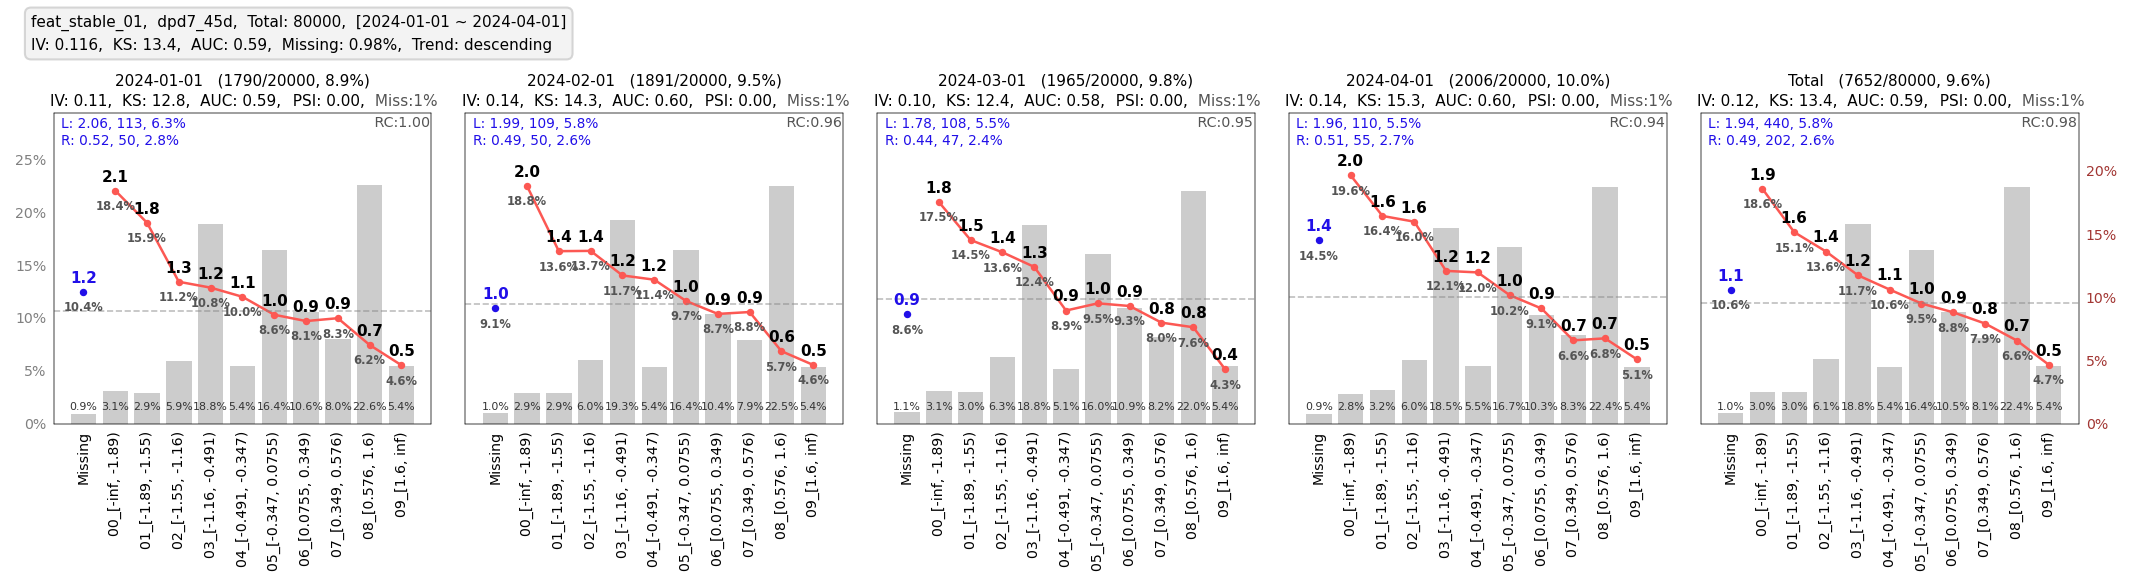

[MARS] 2026-03-01 18:27:43 - INFO - [2/20] Plotting feat_stable_04 (IV=0.0241)...



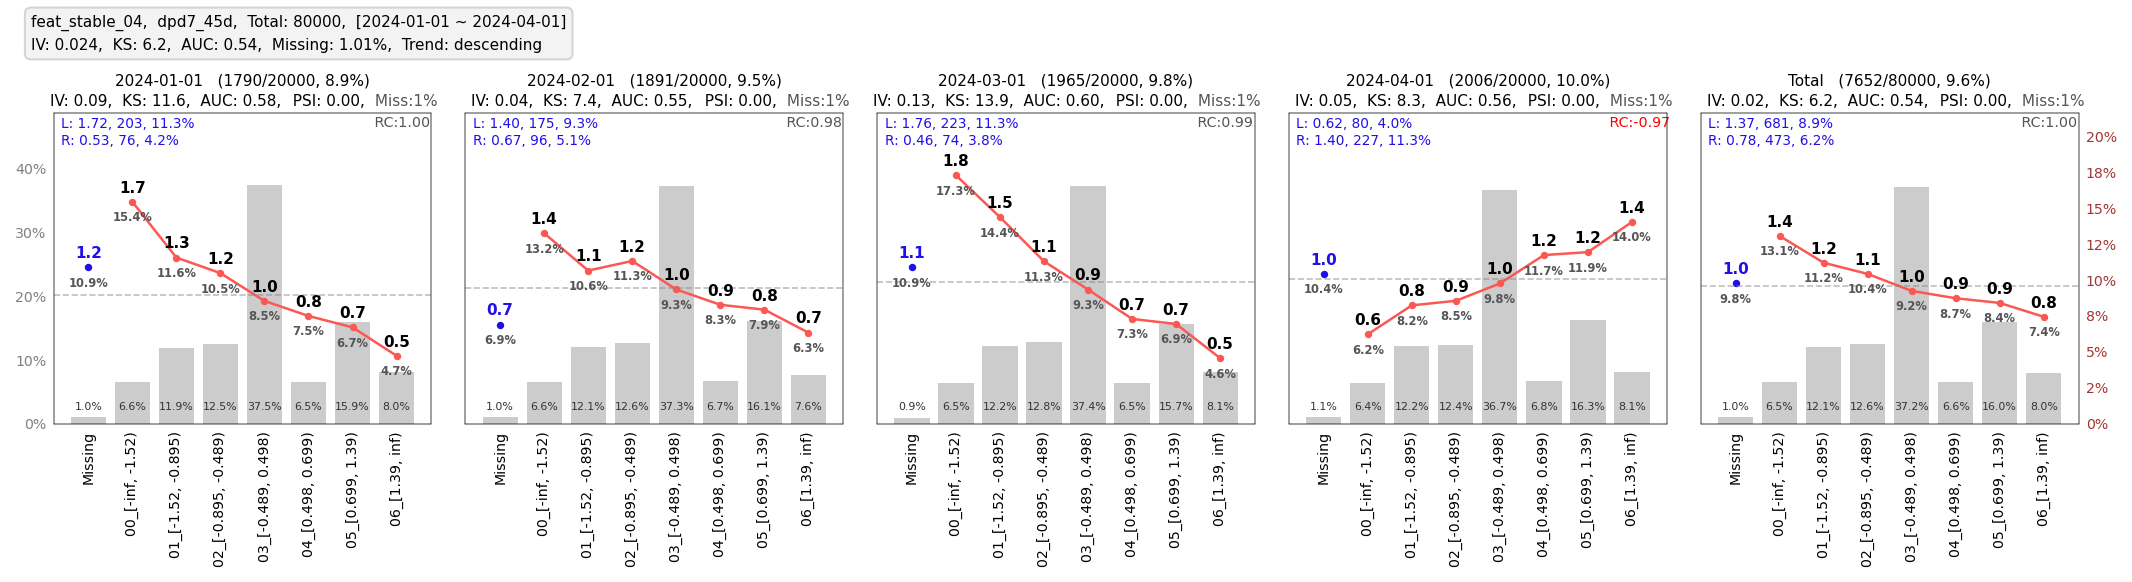

[MARS] 2026-03-01 18:27:44 - INFO - [3/20] Plotting feat_stable_00 (IV=0.0165)...



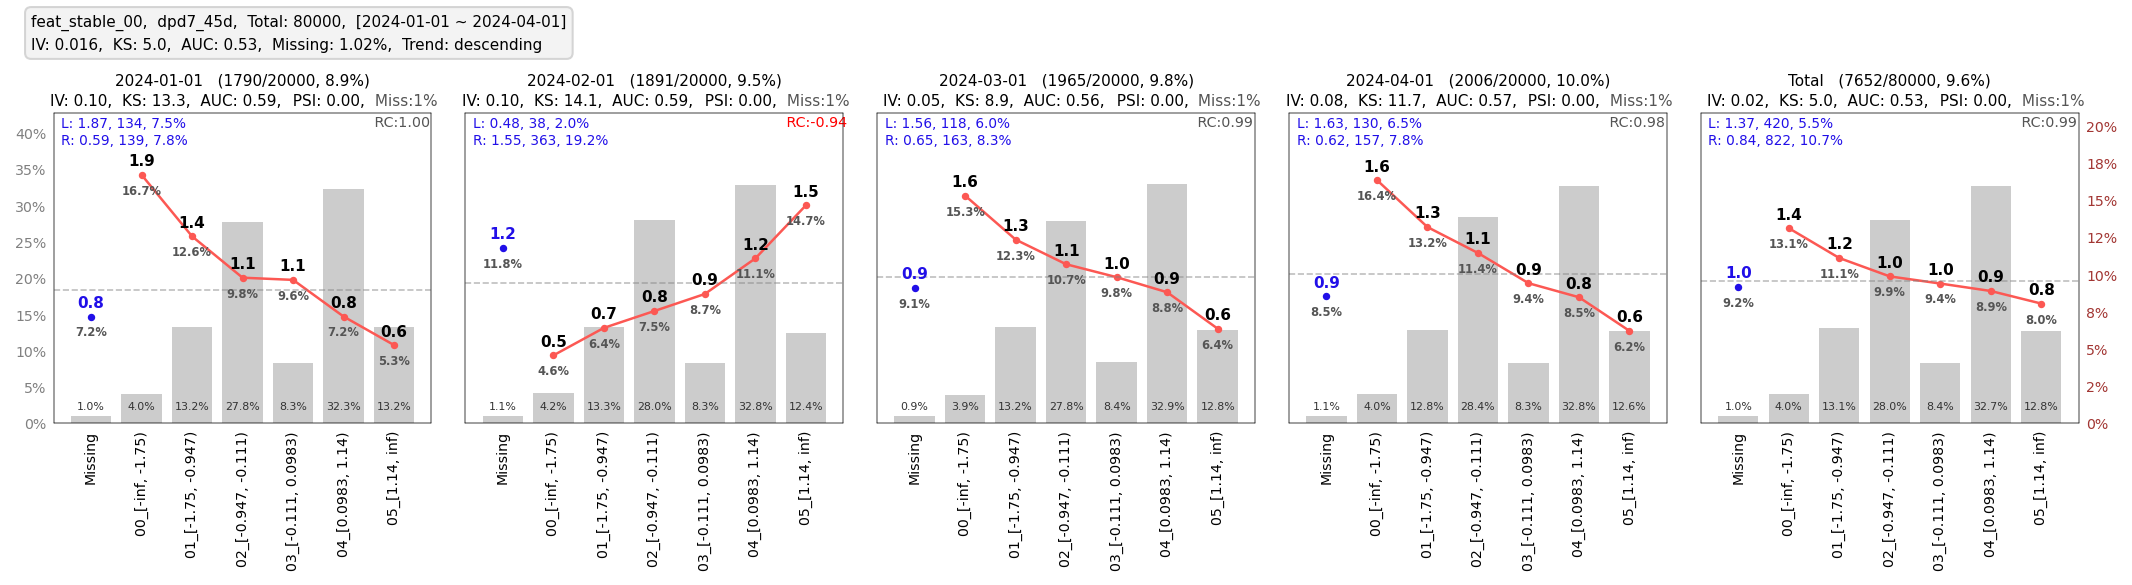

[MARS] 2026-03-01 18:27:44 - INFO - [4/20] Plotting feat_miss_01 (IV=0.0134)...



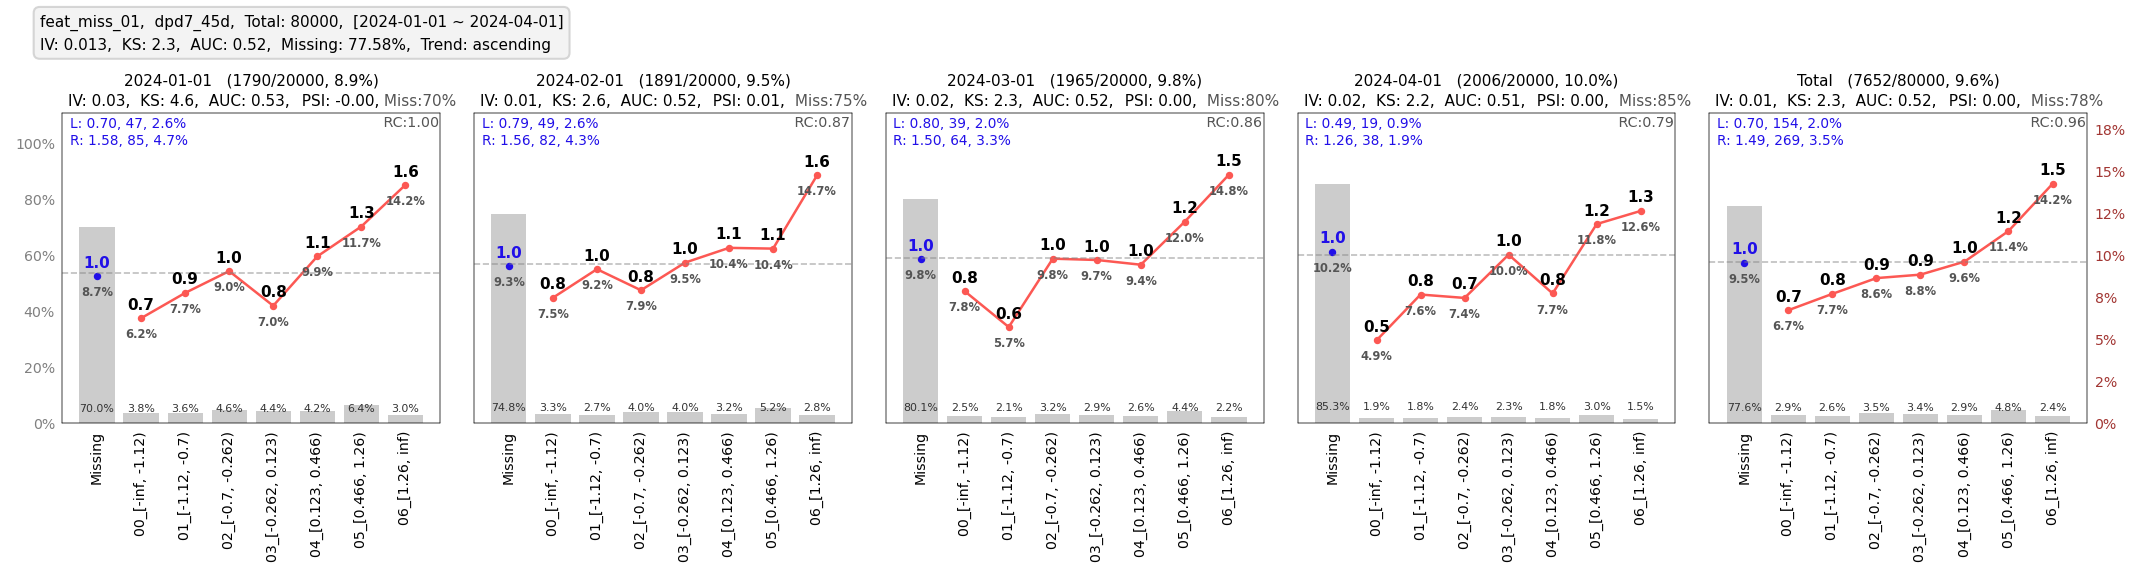

[MARS] 2026-03-01 18:27:44 - INFO - [5/20] Plotting feat_miss_02 (IV=0.0131)...



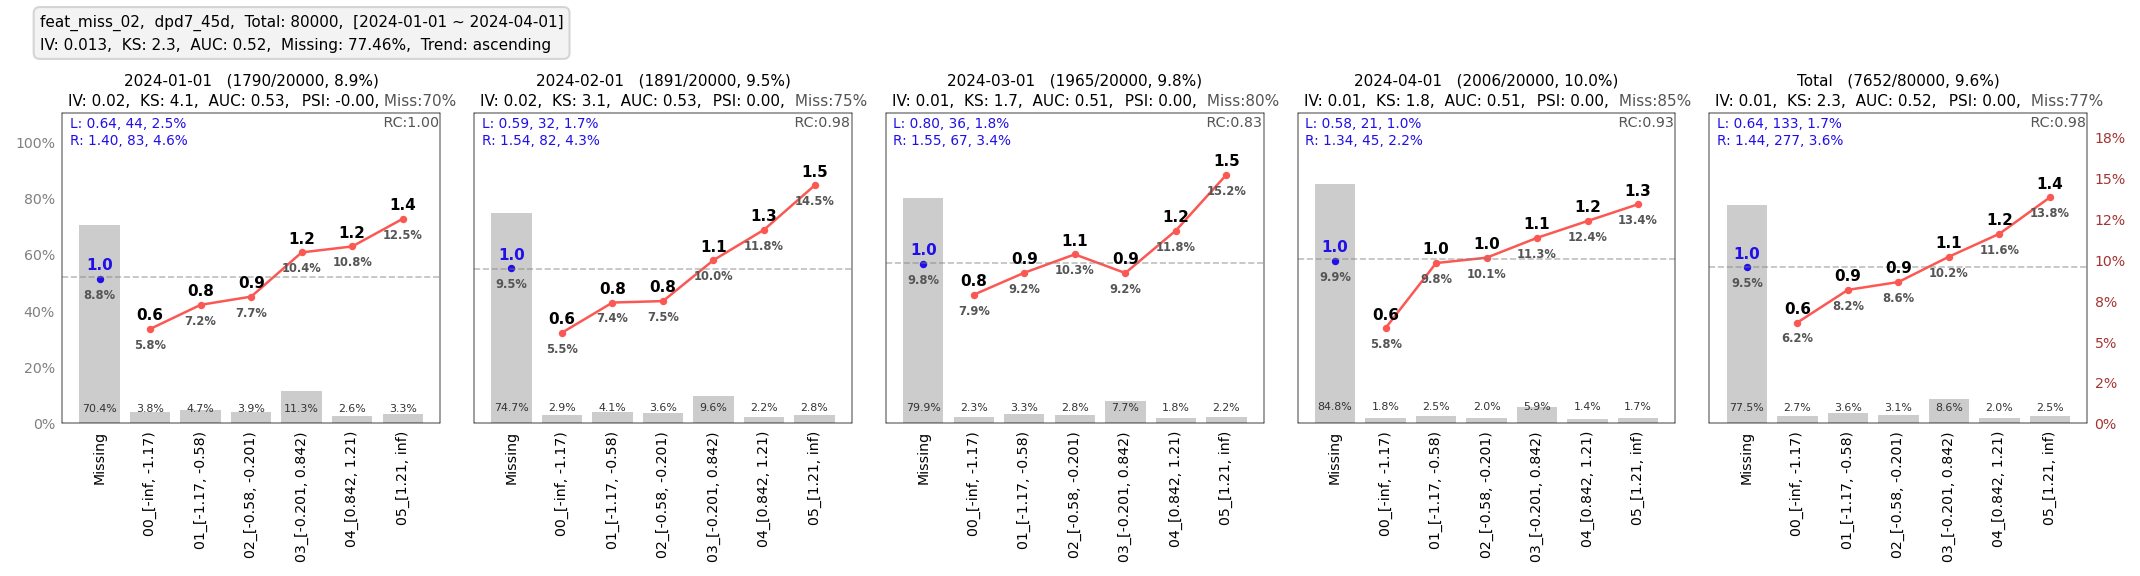

[MARS] 2026-03-01 18:27:45 - INFO - [6/20] Plotting feat_drift_00 (IV=0.0120)...



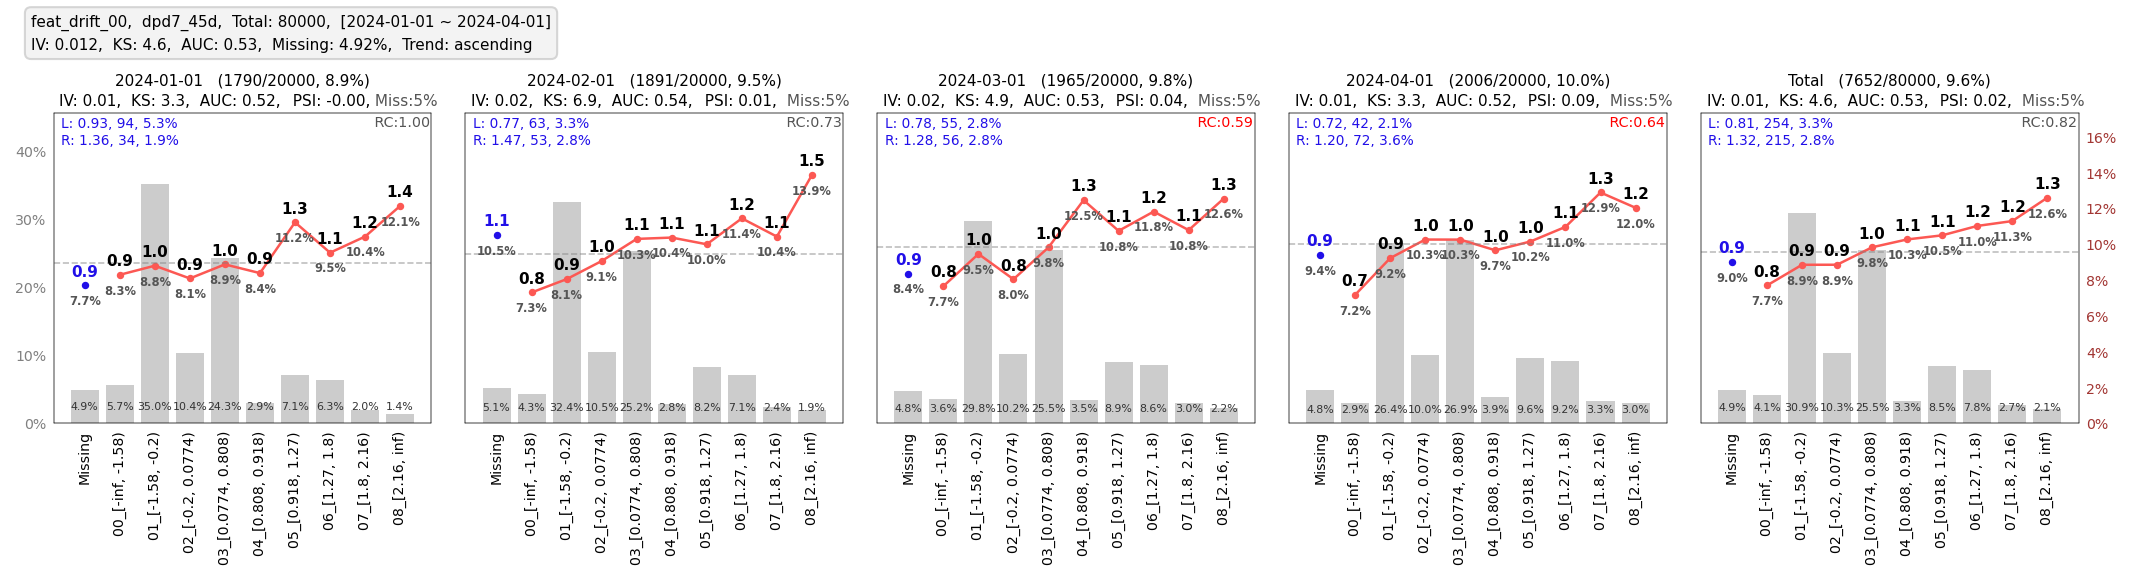

[MARS] 2026-03-01 18:27:45 - INFO - [7/20] Plotting feat_drift_04 (IV=0.0119)...



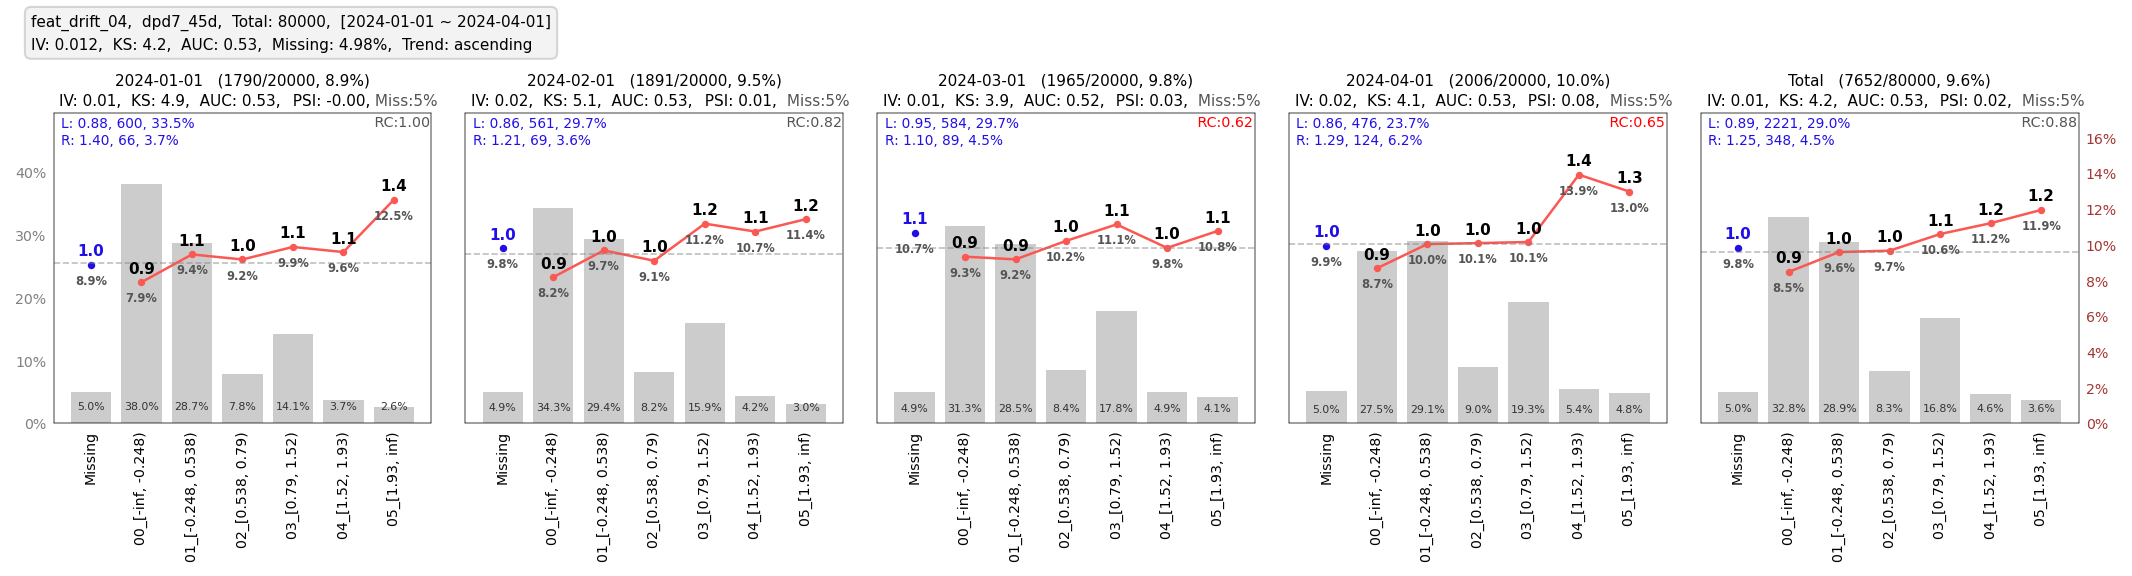

[MARS] 2026-03-01 18:27:46 - INFO - [8/20] Plotting feat_drift_03 (IV=0.0119)...



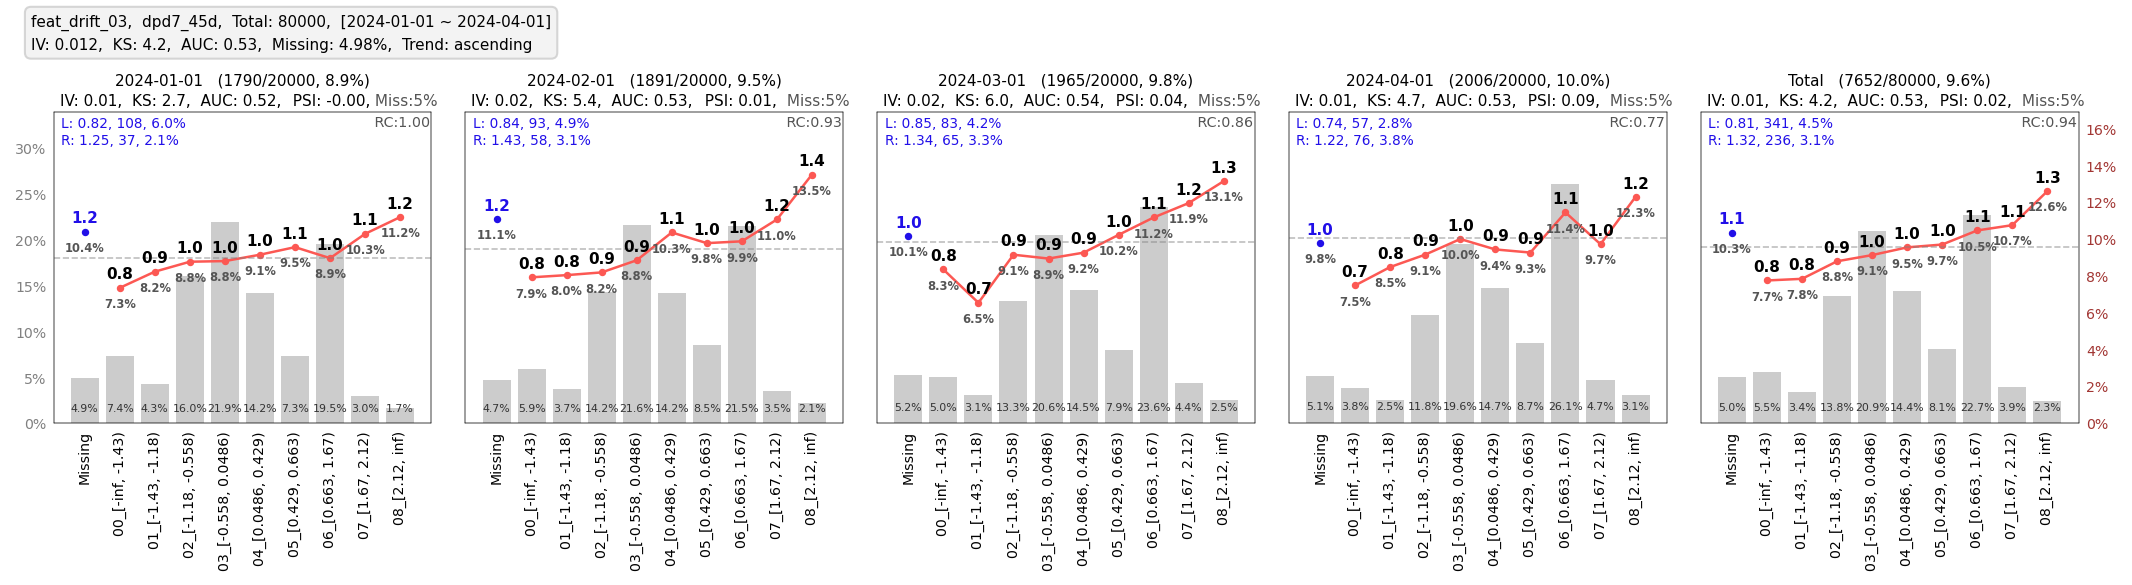

[MARS] 2026-03-01 18:27:46 - INFO - [9/20] Plotting feat_drift_01 (IV=0.0101)...



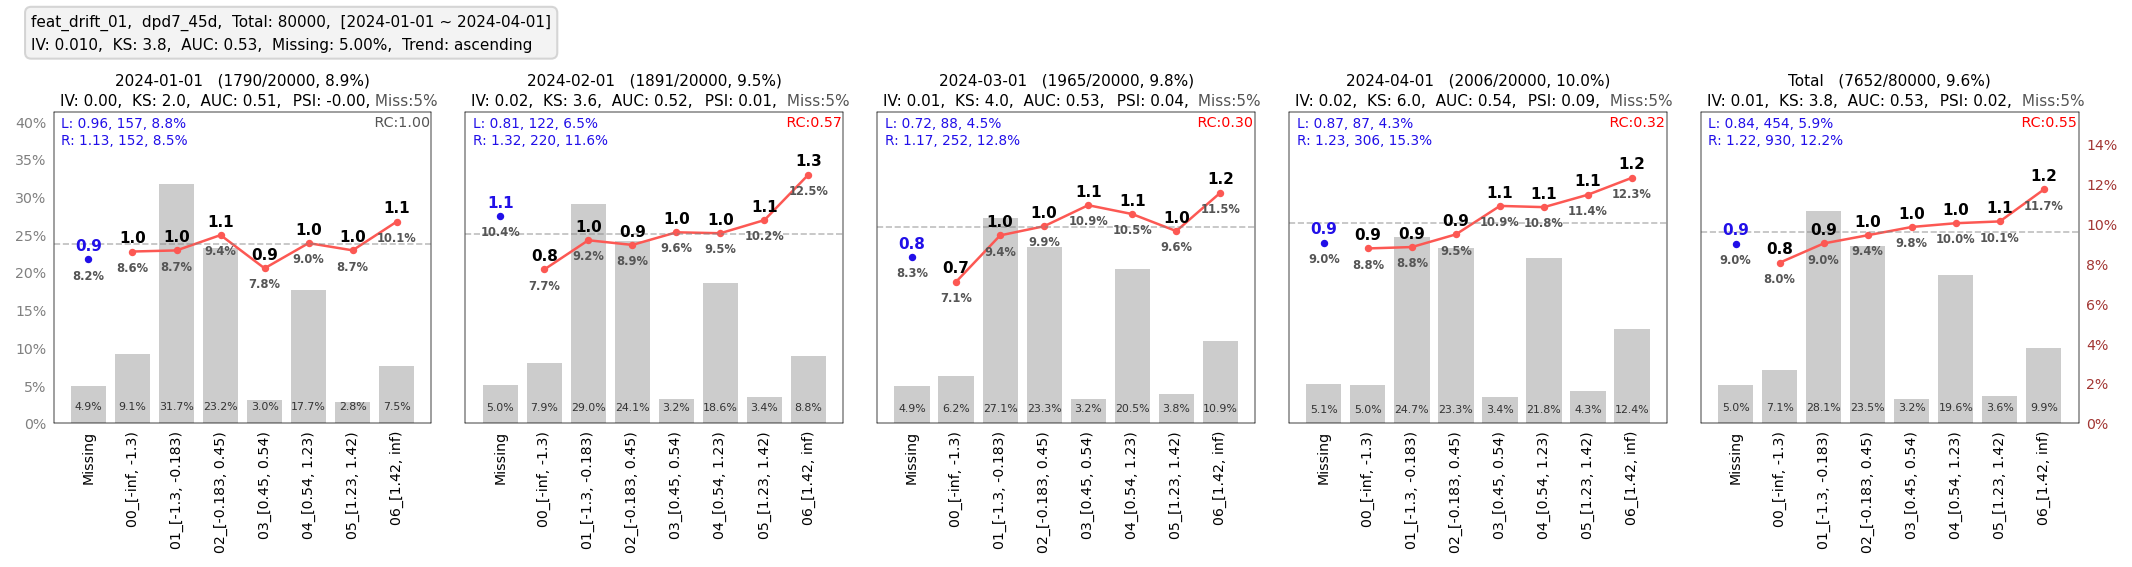

[MARS] 2026-03-01 18:27:47 - INFO - [10/20] Plotting feat_drift_02 (IV=0.0096)...



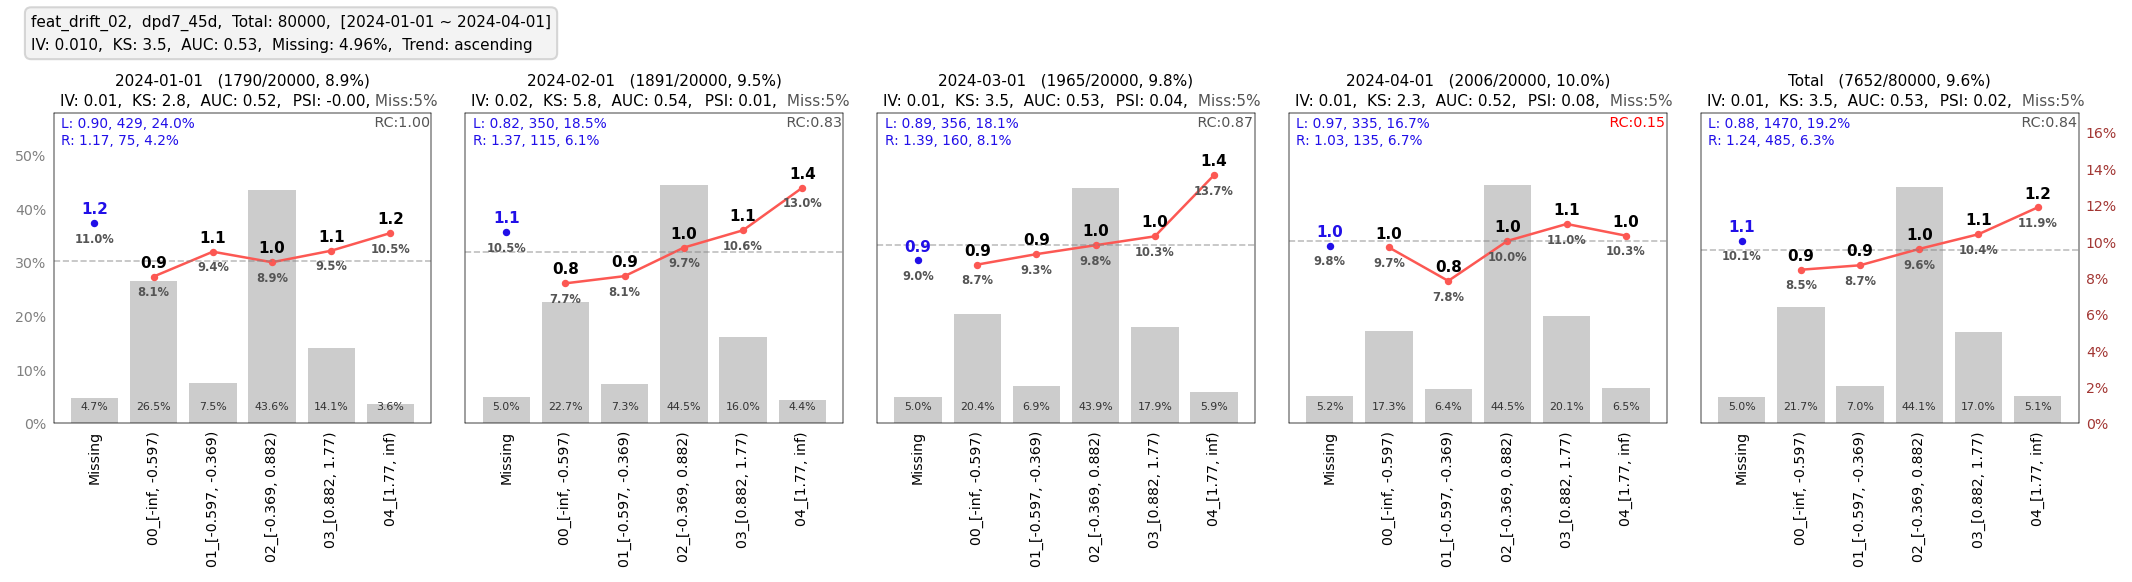

[MARS] 2026-03-01 18:27:47 - INFO - [11/20] Plotting feat_stable_03 (IV=0.0095)...



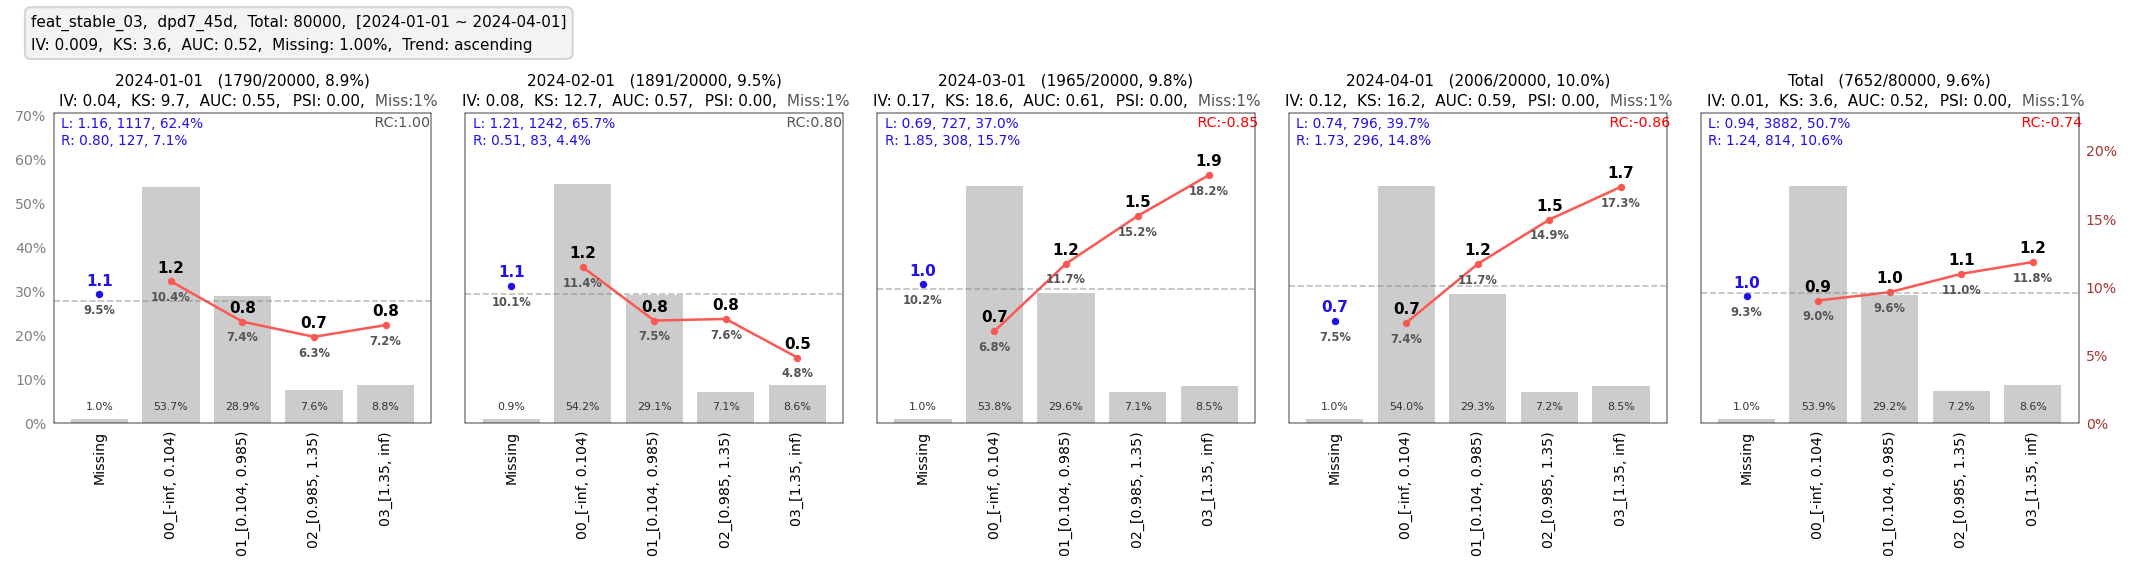

[MARS] 2026-03-01 18:27:48 - INFO - [12/20] Plotting feat_miss_00 (IV=0.0085)...



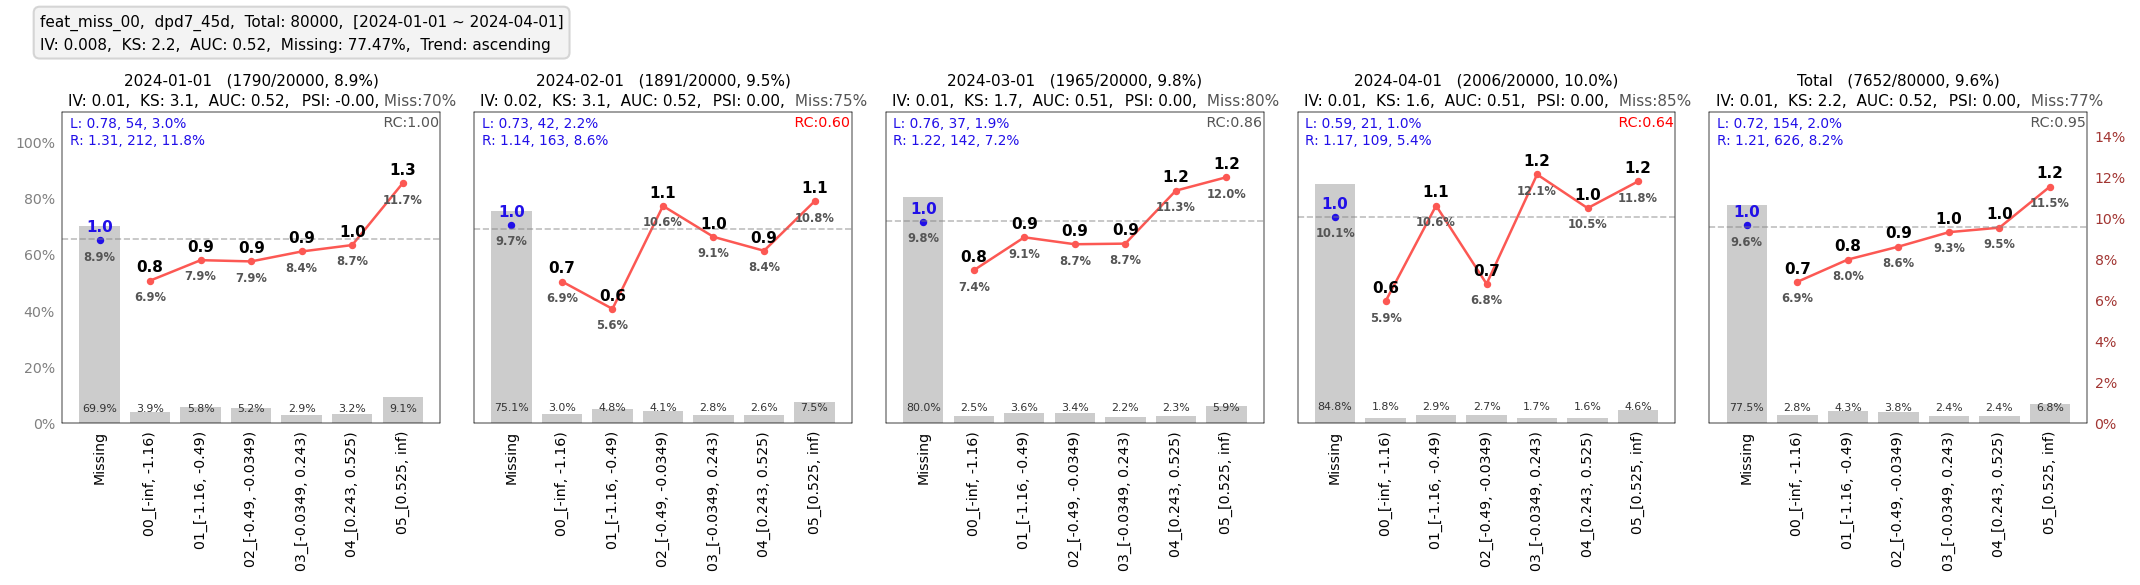

[MARS] 2026-03-01 18:27:48 - INFO - [13/20] Plotting feat_miss_04 (IV=0.0068)...



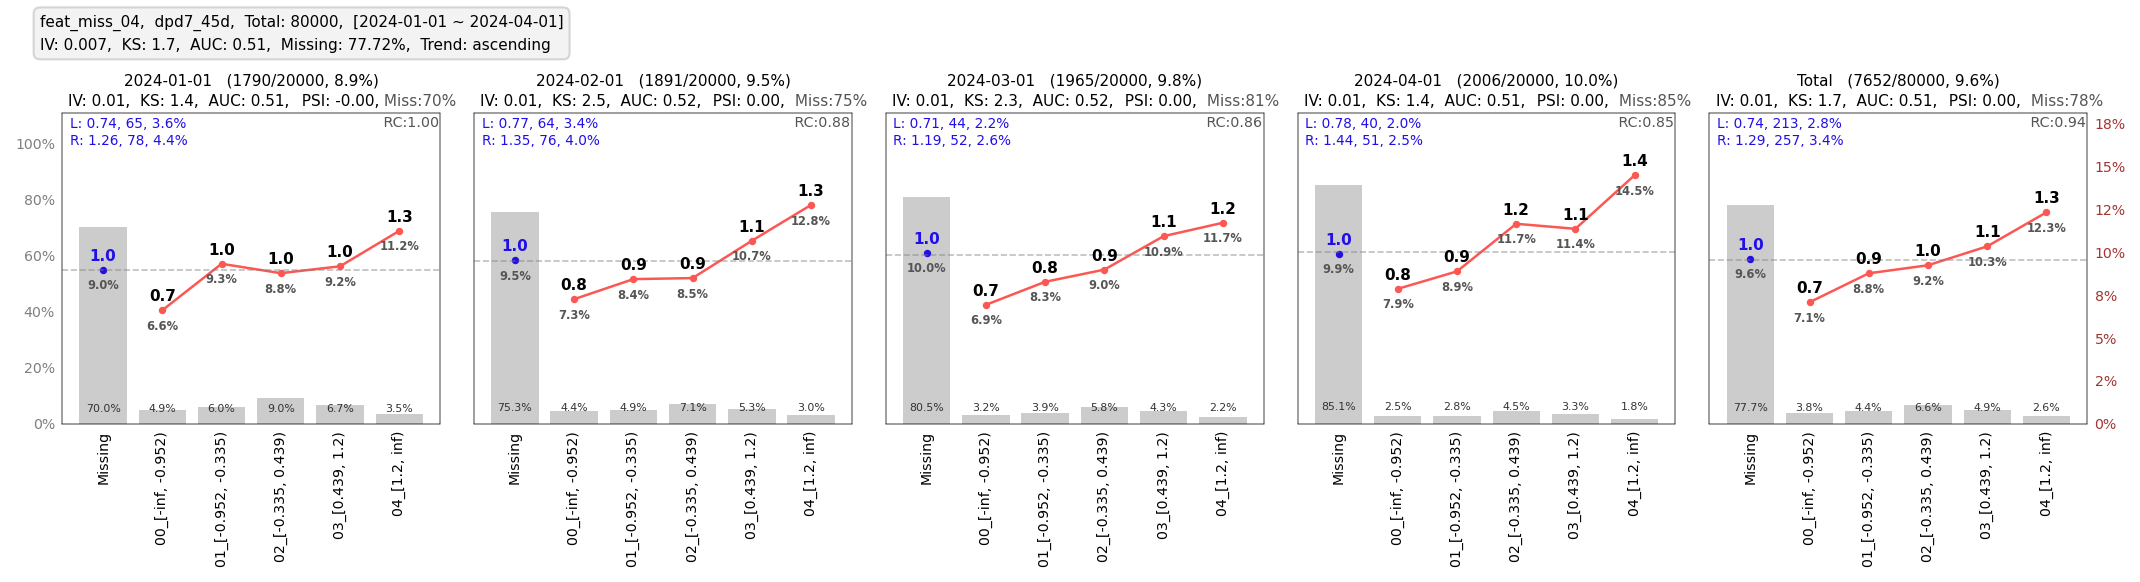

[MARS] 2026-03-01 18:27:48 - INFO - [14/20] Plotting feat_miss_03 (IV=0.0061)...



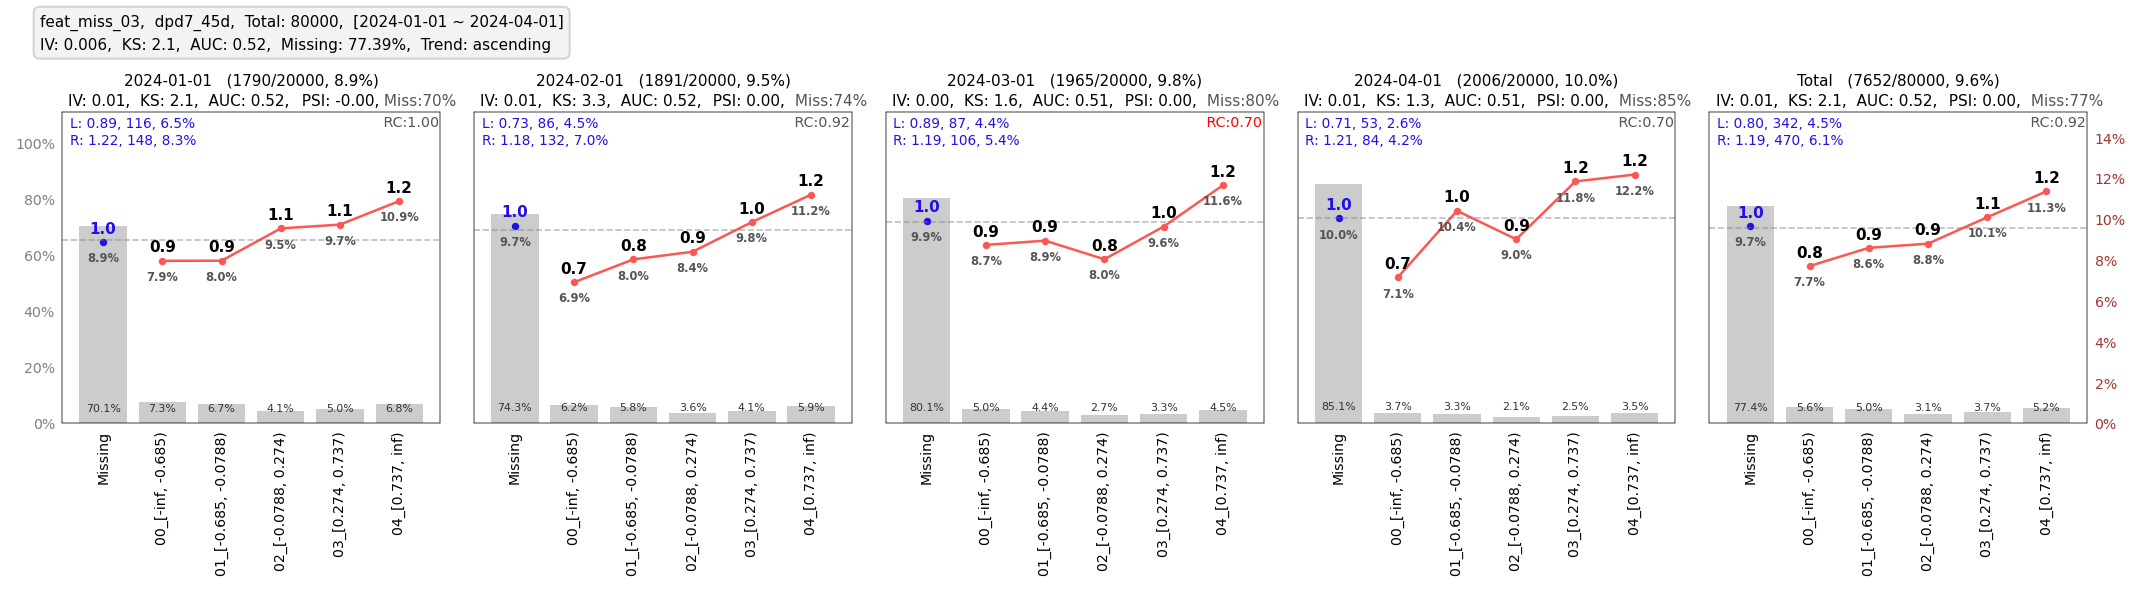

[MARS] 2026-03-01 18:27:49 - INFO - [15/20] Plotting feat_stable_02 (IV=0.0027)...



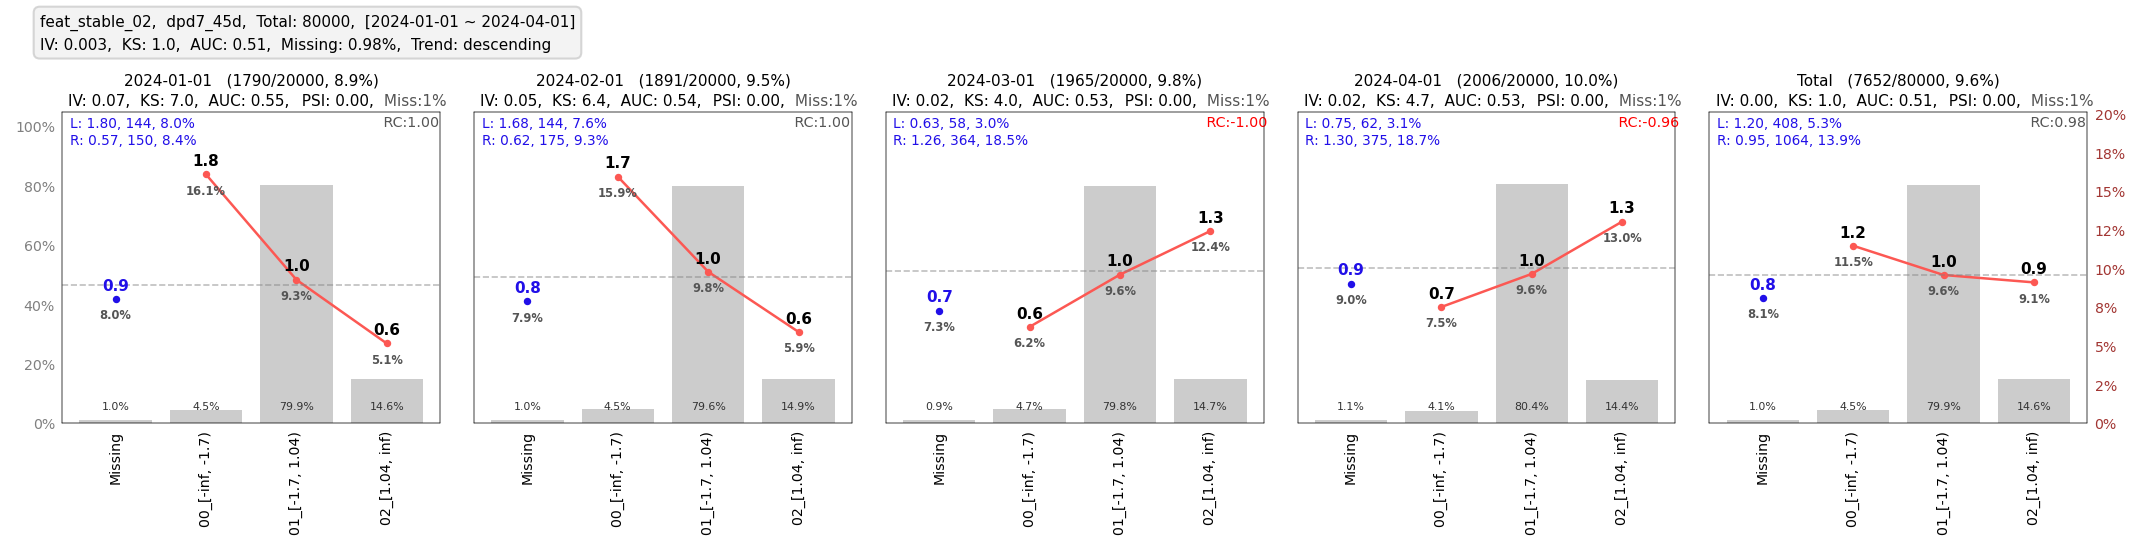

[MARS] 2026-03-01 18:27:49 - INFO - [16/20] Plotting feat_noise_00 (IV=0.0014)...



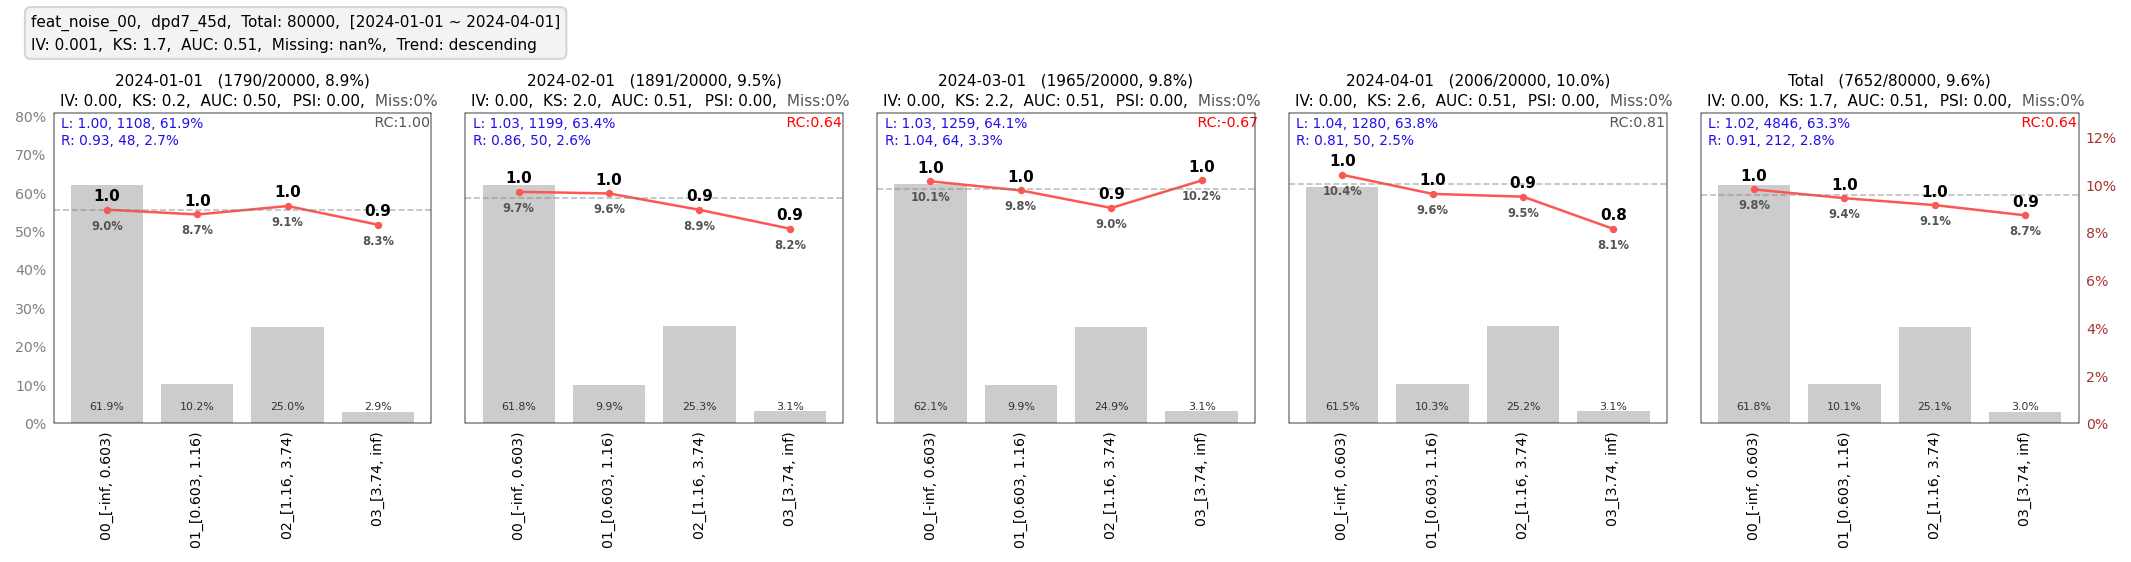

[MARS] 2026-03-01 18:27:50 - INFO - [17/20] Plotting feat_noise_03 (IV=0.0010)...



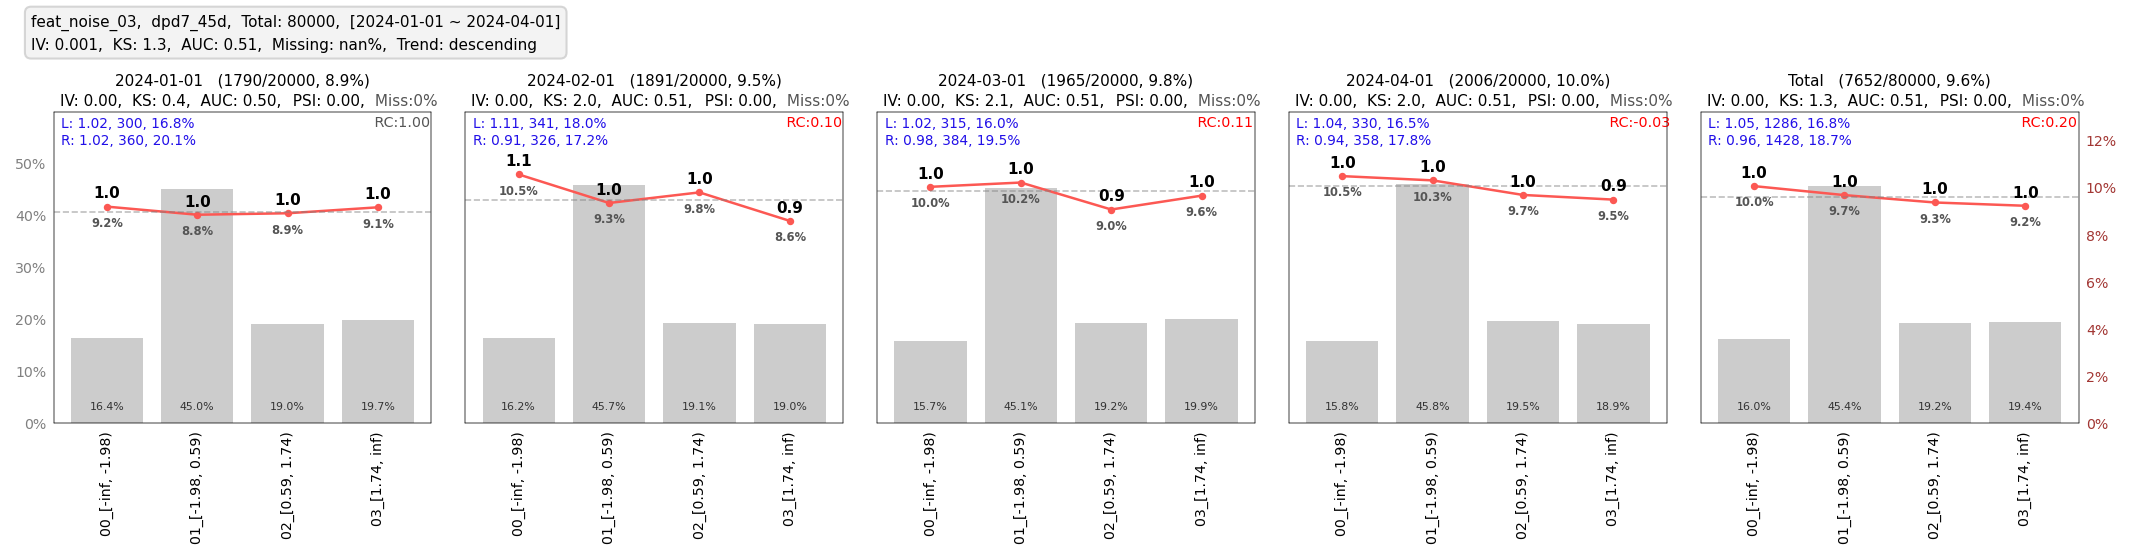

[MARS] 2026-03-01 18:27:50 - INFO - [18/20] Plotting feat_noise_01 (IV=0.0003)...



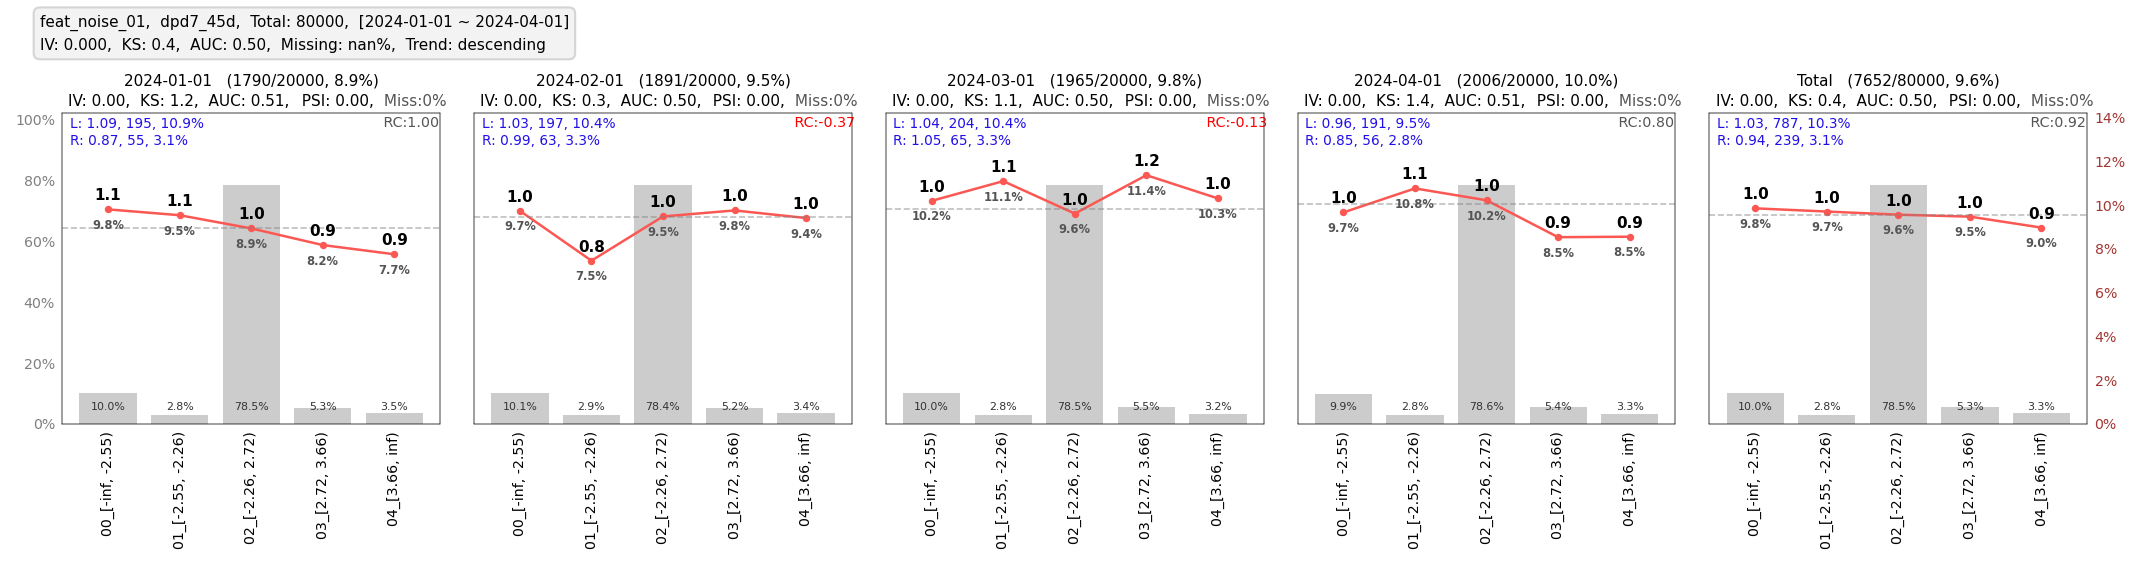

[MARS] 2026-03-01 18:27:50 - INFO - [19/20] Plotting feat_noise_02 (IV=0.0002)...



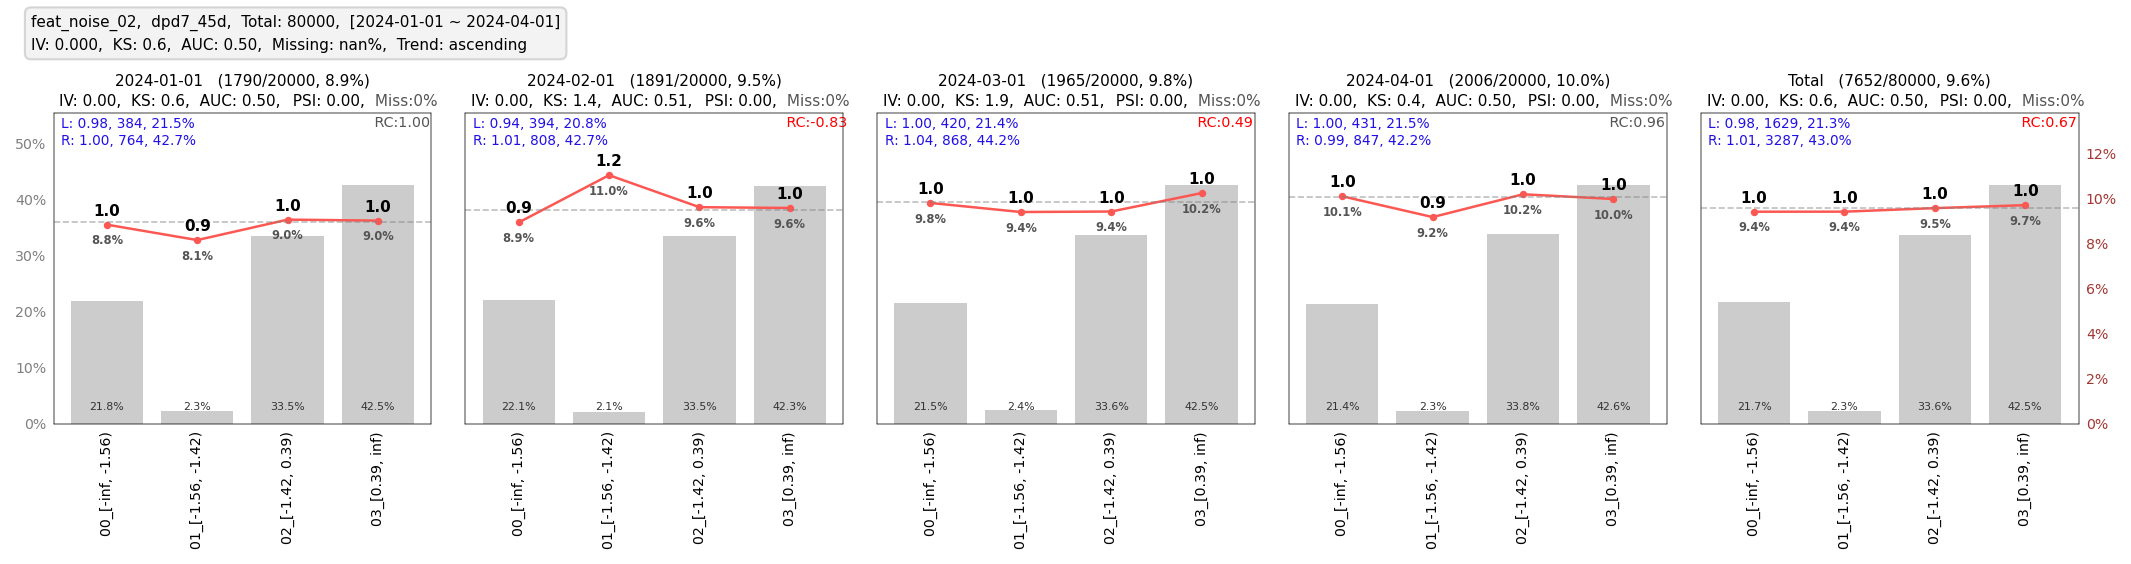

[MARS] 2026-03-01 18:27:51 - INFO - [20/20] Plotting feat_noise_04 (IV=0.0000)...



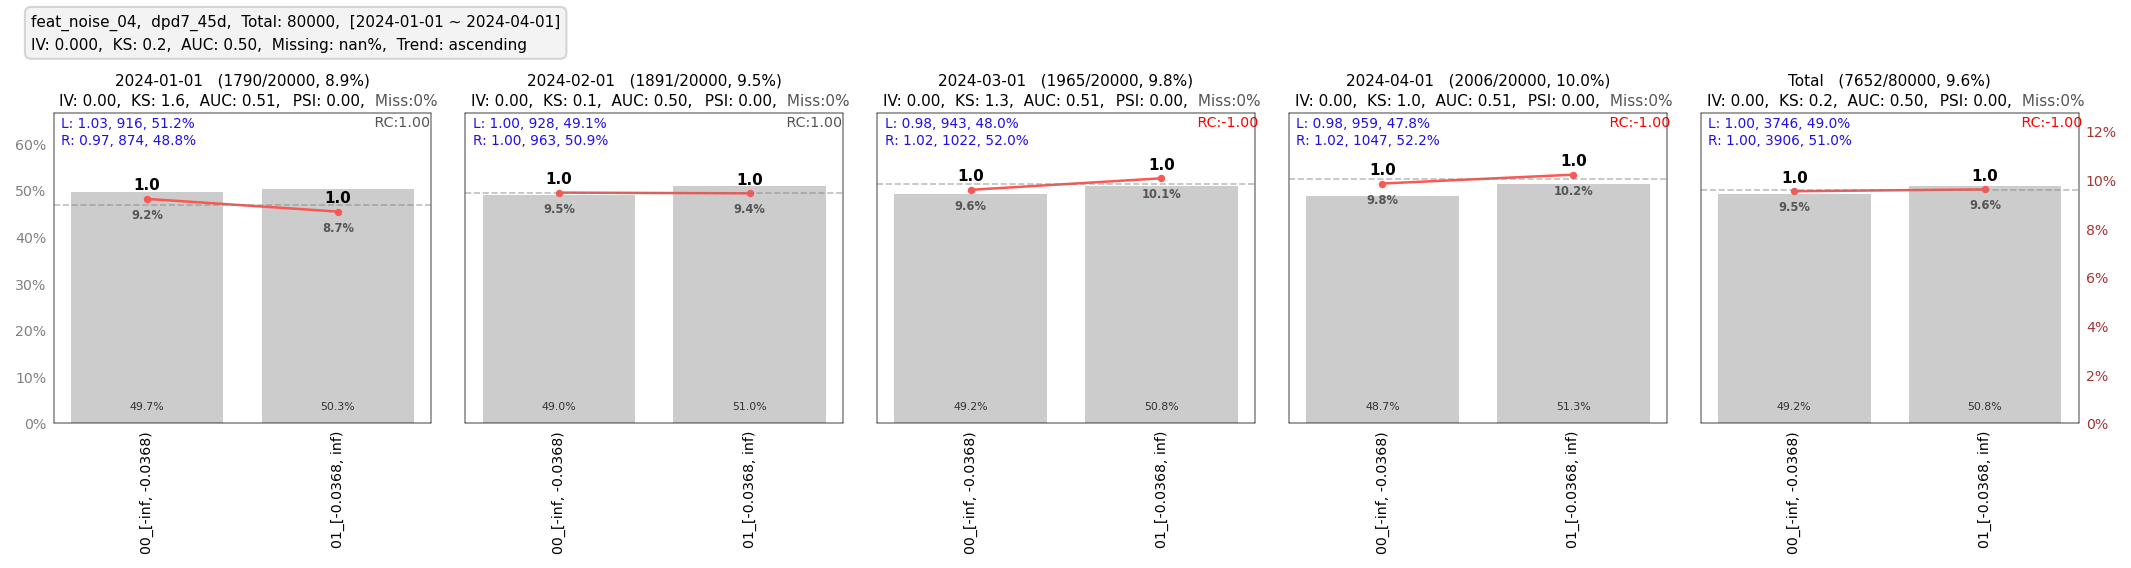

[MARS] 2026-03-01 18:27:51 - INFO - ✅ Batch plotting completed.


In [33]:
set_log_level("INFO")
test_evaluator.plot_feature_binning_risk_trends(
    report=test_evaluator_report,
    features=features,
    sort_by="iv",
    dpi=150
)